# 키워드 확정 루프 — 증거 기반 (흥행 *유발* 검증)

> 목적: 파라미터 조정 → 나온 키워드가 **진짜 흥행을 유발**하는지 4축 증거로 확인 → 확정 → 대시보드 연결.
> 4축: ① 통계(purity·성공률) ② **인과(Δprob: 더하면 성공확률 오르나)** ③ 실증(실매출) ④ 지지도.

```
[튜닝] EngineConfig 임계 조정 → 장부 재생성
   ↓
[검토] evidence_table 로 Δprob·매출 스캔 → 단일 키워드 drill-down
   ↓  (반복)
[확정] keyword_final.csv 저장 (include/tag + 증거)
   ↓
[연결] python -m scripts.export_dashboard → dashboard.html 반영
```
**당신이 하는 일**: 셀 돌리며 Δprob≤0인 가짜 killer 골라내고, 임계 조정해 재확인 → 마지막에 CSV 저장.

In [1]:
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if ROOT not in sys.path: sys.path.insert(0, ROOT)
os.chdir(ROOT)
import numpy as np, pandas as pd
pd.set_option("display.max_rows", 200)
from src.eval.md.engine import MDEngine, EngineConfig
from src.eval.md import inspector as I
from src.eval.md.inspector import keyword_evidence, evidence_table, ledger_keywords, export_keyword_final

MODEL = "v2_sweepA"   # "v2_sweepA"(최종 채택) | "exp47"  (장부는 모델 거의 불변)
print("model:", MODEL)

/Users/hajiyoon/workspace/711project/7eleven_npd_share이전/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


model: v2_sweepA


## 1. 엔진 로드 + 장부 (파라미터는 EngineConfig)

In [ ]:
# ★ 파라미터 튜닝 지점 — 값 바꾸고 이 셀부터 다시 실행하면 장부가 바뀜
CFG = (EngineConfig.exp47() if MODEL=="exp47" else EngineConfig.v2_sweepA())
CFG.data_dir = "7eleven_npd_share/data/processed/hin"  # ← 이 줄 추가
CFG.device = "mps"
CFG.killer_purity = 0.50   # killer purity 하한 (base 0.238 위)
CFG.killer_top_q  = 0.75   # Score_succ 상위 25%
CFG.mine_purity   = 0.15   # mine purity 상한
CFG.hub_top_q     = 0.80   # Hub_Score 상위 20%
CFG.hub_balance_eps = 0.15 # |purity-base| 균형 게이트

eng = MDEngine(CFG).run_single_inference(); eng.build_mass(); lg = eng.build_ledger("full")
print(f"killer {len(lg.killer)} / mine {len(lg.mine)} / hub {len(lg.hub)} / neutral {eng.cache['K']-len(lg.killer|lg.mine|lg.hub)}")

killer 62 / mine 131 / hub 144 / neutral 1726


## 2. 증거 스캔 — killer가 진짜 흥행을 유발하나 (Δprob)

In [5]:
killers = ledger_keywords(eng, "killer")
tbl = evidence_table(eng, killers)
# Δprob>0 = 흥행 유발(인과 확인) / Δprob≤0 = 상관만 (가짜 killer 의심)
tbl = tbl.sort_values("delta_prob_mean", ascending=False)
print(f"killer {len(tbl)}개 중 Δprob>0(진짜 유발): {(tbl['delta_prob_mean']>0).sum()}개 / Δprob≤0(상관만): {(tbl['delta_prob_mean']<=0).sum()}개")
display(tbl)

killer 62개 중 Δprob>0(진짜 유발): 28개 / Δprob≤0(상관만): 34개


,keyword,tag,성공률,base_rate,purity,balance,support_succ,support_fail,delta_prob_mean,delta_prob_pos_rate,매출중앙값,hub_score
41,젤리블리,killer,1.000,0.238,1.000,0.762,4,0,0.1336,1.00,None,0.469
54,하와이,killer,0.833,0.238,0.833,0.596,10,2,0.1292,1.00,None,-0.865
50,포카칩,killer,1.000,0.238,1.000,0.762,3,0,0.1121,1.00,None,0.878
55,한정,killer,0.596,0.238,0.579,0.342,107,76,0.1070,1.00,None,3.391
6,고창,killer,0.800,0.238,0.800,0.562,4,1,0.1059,1.00,None,1.546
27,빈츠,killer,0.800,0.238,0.800,0.562,4,1,0.0863,1.00,None,0.770
45,커스터드,killer,0.611,0.238,0.511,0.273,69,133,0.0811,1.00,None,2.959
34,여유,killer,1.000,0.238,0.800,0.562,7,2,0.0791,1.00,None,-0.419
32,알포트,killer,0.833,0.238,0.833,0.596,5,1,0.0773,1.00,None,1.039
25,뷰티,killer,1.000,0.238,0.875,0.637,7,2,0.0728,1.00,None,-0.411


In [5]:
# mine / hub 도 같은 방식
print("── MINE (Δprob<0 이어야 진짜 악재) ──"); display(evidence_table(eng, ledger_keywords(eng,"mine")).sort_values("delta_prob_mean"))
print("── HUB (balance 작아야 진짜 일반어) ──"); display(evidence_table(eng, ledger_keywords(eng,"hub")).sort_values("balance"))

── MINE (Δprob<0 이어야 진짜 악재) ──


,keyword,tag,성공률,base_rate,purity,balance,support_succ,support_fail,delta_prob_mean,delta_prob_pos_rate,매출중앙값,hub_score
58,순수,mine,0.000,0.238,0.079,0.159,3,18,-0.1844,0.00,NaN,3.632
116,피규어,mine,0.000,0.238,0.142,0.096,19,50,-0.1742,0.00,5000.0,1.150
64,식후,mine,0.000,0.238,0.095,0.143,4,19,-0.1661,0.07,NaN,0.437
33,밀키트,mine,0.000,0.238,0.149,0.088,13,24,-0.1613,0.00,15010.0,-0.715
122,해장,mine,0.000,0.238,0.141,0.097,49,135,-0.1612,0.00,11700.0,-0.914
118,한우,mine,0.000,0.238,0.000,0.238,0,14,-0.1592,0.00,21850.0,-1.663
97,축구,mine,0.000,0.238,0.000,0.238,0,5,-0.1517,0.00,NaN,-2.247
35,벚꽃,mine,0.000,0.238,0.000,0.238,0,4,-0.1502,0.00,1283162.0,-1.250
111,펭귄,mine,0.000,0.238,0.000,0.238,0,13,-0.1464,0.00,1516671.0,-0.534
124,향신료,mine,0.000,0.238,0.125,0.113,6,22,-0.1430,0.00,263915.0,-0.748


── HUB (balance 작아야 진짜 일반어) ──


,keyword,tag,성공률,base_rate,purity,balance,support_succ,support_fail,delta_prob_mean,delta_prob_pos_rate,매출중앙값,hub_score
119,토스트,hub,0.235,0.238,0.235,0.003,4,13,-0.0293,0.53,1759448.0,1.206
118,키치,hub,NaN,0.238,0.241,0.003,13,41,-0.0614,0.47,NaN,1.637
40,맛,hub,0.333,0.238,0.244,0.006,29,88,-0.0108,0.60,7660100.0,1.846
134,피자,hub,0.204,0.238,0.245,0.007,33,103,-0.0192,0.73,5889520.0,1.925
96,젤리,hub,0.314,0.238,0.246,0.008,126,270,-0.0467,0.33,630070.0,3.678
79,스파게티,hub,0.154,0.238,0.246,0.008,8,18,-0.0775,0.00,6839252.0,2.954
35,리본,hub,0.000,0.238,0.229,0.009,11,16,-0.0522,0.20,NaN,2.961
3,간식,hub,0.338,0.238,0.229,0.009,968,2332,0.0215,1.00,2680139.0,1.860
14,김밥,hub,0.318,0.238,0.229,0.009,98,207,-0.0743,0.07,15445631.0,1.172
26,도시락,hub,0.241,0.238,0.249,0.011,406,1048,-0.1767,0.00,1040000.0,2.708


# 2-2. 허브 파라미터 그리드 서치

In [21]:
import numpy as np
import pandas as pd

base_rate = 0.238

# 기존 ledger에서 raw 점수 추출
purity_arr    = lg.purity        # (K,)
hub_score_arr = lg.hub_score     # (K,)
supp_s        = lg.support_succ  # (K,)
supp_f        = lg.support_fail  # (K,)
supp_all      = supp_s + supp_f

# 파라미터 그리드
top_q_vals = [0.70, 0.75, 0.80, 0.85, 0.90]
eps_vals   = [0.05, 0.10, 0.15, 0.20, 0.25]

rows = []
for top_q in top_q_vals:
    for eps in eps_vals:
        hub_thr  = np.quantile(hub_score_arr, top_q)
        hub_mask = (
            (supp_all >= 3) &
            (hub_score_arr >= hub_thr) &
            (np.abs(purity_arr - base_rate) < eps)
        )
        hub_set = set(np.where(hub_mask)[0]) - lg.killer - lg.mine
        n = len(hub_set)

        lifts = [att_lift[k] for k in hub_set]
        true_hub   = sum(1 for l in lifts if 0.7 <= l <= 1.3)
        hid_killer = sum(1 for l in lifts if l > 1.3)
        fail_bias  = sum(1 for l in lifts if 0 < l < 0.7)
        isolated   = sum(1 for l in lifts if l == 0)

        rows.append({
            "top_q": top_q, "eps": eps,
            "hub_n": n,
            "true_hub": true_hub,
            "hid_killer": hid_killer,
            "fail_bias": fail_bias,
            "isolated": isolated,
            "진짜허브%": round(true_hub / max(n, 1) * 100),
        })

df_sw = pd.DataFrame(rows)

for col in ["hub_n", "true_hub", "진짜허브%", "hid_killer"]:
    print(f"\n=== {col} (행=eps, 열=top_q) ===")
    print(df_sw.pivot(index="eps", columns="top_q", values=col).to_string())



=== hub_n (행=eps, 열=top_q) ===
top_q  0.70  0.75  0.80  0.85  0.90
eps                                
0.05     98    78    62    47    30
0.10    205   166   131   102    67
0.15    248   202   164   128    87
0.20    278   230   185   141    97
0.25    320   265   211   159   110

=== true_hub (행=eps, 열=top_q) ===
top_q  0.70  0.75  0.80  0.85  0.90
eps                                
0.05     56    43    33    22    13
0.10     74    57    47    32    22
0.15     80    62    52    37    27
0.20     83    65    55    38    28
0.25     84    66    56    39    29

=== 진짜허브% (행=eps, 열=top_q) ===
top_q  0.70  0.75  0.80  0.85  0.90
eps                                
0.05     57    55    53    47    43
0.10     36    34    36    31    33
0.15     32    31    32    29    31
0.20     30    28    30    27    29
0.25     26    25    27    25    26

=== hid_killer (행=eps, 열=top_q) ===
top_q  0.70  0.75  0.80  0.85  0.90
eps                                
0.05     20    17    15    14    11


In [23]:
rows = []
for kp in killer_purity_vals:
    for eps in eps_vals:
        # ★ 수정: 지지도≥3 키워드 내에서만 분위수 계산
        elig_k = supp_s >= 3
        elig_f = supp_f >= 3
        elig_h = supp_all >= 3

        k_thr = np.quantile(lg.score_succ[elig_k], 0.75)
        m_thr = np.quantile(lg.score_fail[elig_f], 0.75)
        h_thr = np.quantile(hub_score_arr[elig_h], 0.80)

        k_mask = elig_k & (purity_arr >= kp) & (lg.score_succ >= k_thr)
        m_mask = elig_f & (purity_arr <= 0.15) & (lg.score_fail >= m_thr)
        h_mask = elig_h & (hub_score_arr >= h_thr) & (np.abs(purity_arr - base_rate) < eps)

        k_set = set(np.where(k_mask)[0])
        m_set = set(np.where(m_mask)[0])
        h_set = set(np.where(h_mask)[0]) - k_set - m_set

        k_ok = sum(1 for k in k_set if att_lift[k] >= 1.5)
        h_ok = sum(1 for k in h_set if 0.7 <= att_lift[k] <= 1.3)

        rows.append({
            "kp": kp, "eps": eps,
            "killer": len(k_set),
            "killer확정%": round(k_ok/max(len(k_set),1)*100),
            "mine": len(m_set),
            "hub": len(h_set),
            "hub순도%": round(h_ok/max(len(h_set),1)*100),
            "coverage%": round(len(k_set|m_set|h_set)/2039*100),
        })

df_joint = pd.DataFrame(rows)
print(df_joint.to_string(index=False))


  kp  eps  killer  killer확정%  mine  hub  hub순도%  coverage%
0.40 0.05      83         69   131   54      50         13
0.40 0.10      83         69   131  116      34         16
0.40 0.15      83         69   131  144      31         18
0.40 0.20      83         69   131  156      29         18
0.45 0.05      72         76   131   54      50         13
0.45 0.10      72         76   131  116      34         16
0.45 0.15      72         76   131  144      31         17
0.45 0.20      72         76   131  159      29         18
0.50 0.05      62         74   131   54      50         12
0.50 0.10      62         74   131  116      34         15
0.50 0.15      62         74   131  144      31         17
0.50 0.20      62         74   131  159      29         17
0.55 0.05      52         81   131   54      50         12
0.55 0.10      52         81   131  116      34         15
0.55 0.15      52         81   131  144      31         16
0.55 0.20      52         81   131  159      29         

스윕 결과

hub는 eps만, killer는 kp만 결정해요. 두 파라미터가 완전히 독립이에요.

killer 품질 (kp):

kp	killer 수	확정%	실제 확정
0.40	83	69%	~57
0.45	72	76%	~55
0.50	62	74%	~46 (현재)
0.55	52	81%	~42
0.60	48	81%	~39
kp=0.55부터 확정률이 81%로 올라가고, 0.60으로 올려도 개수만 줄고 순도는 그대로예요. 0.55가 변곡점이에요.

hub 품질 (eps):

eps	hub 수	순도%
0.05	54	50% (최대)
0.10	116	34%
0.15	144	31% (현재)
hub 순도는 파라미터로 50% 이상 올릴 수 없어요. 이건 구조적 한계예요. att_lift로 보면 절반은 항상 성공/실패 편향이 있어요.

결론
파라미터 조정으로 얻을 수 있는 최선:

kp=0.55, eps=0.05: killer 52개(81% 확정), hub 54개(50% 순도), coverage 12%
현재 대비 killer는 더 정확해지지만 개수가 줄고, hub는 절반까지만 정화돼요.

hub 순도 문제는 파라미터로 해결이 안 돼요. att_lift 후처리로 hub 내 성공편향 키워드를 별도 처리하는 게 유일한 방법이에요. kp=0.55, eps=0.05로 파라미터를 설정하고, hub 안의 숨겨진 killer는 "증폭 키워드" 태그로 후처리하는 조합이 가장 합리적이에요.


사실 이 파라미터 서치가 가리키는 진짜 결론은:

파라미터로 "완벽한 조합"을 찾으려는 게 잘못된 접근이에요. 어떤 조합을 써도 att_lift 후처리가 필요하고, att_lift 후처리를 할 거라면 첫 단계 파라미터의 차이가 크지 않아요.

그래서 실질적 결론은:

현재 설정(kp=0.50, eps=0.15) 그대로 두고
att_lift로 각 그룹을 검증하고 재분류하는 게 맞아요

### 파라미터 조정 후, 그룹별 적절한 파라미터 찾기 검증

In [24]:
import numpy as np
import pandas as pd

prob = cache["prob"]   # (N,) 예측 성공확률
base_rate = 0.238

# ── 1. WoE ─────────────────────────────────────────────
supp_s = lg.support_succ
supp_f = lg.support_fail
woe = np.log((supp_s / n_succ + 1e-9) / (supp_f / n_fail + 1e-9))

# ── 2. prob_lift ────────────────────────────────────────
ei   = cache["eidx"][("product","has_kw","keyword")].numpy()
ps, ks = ei[0], ei[1]
prob_sum = np.zeros(K); prob_cnt = np.zeros(K)
np.add.at(prob_sum, ks, prob[ps])
np.add.at(prob_cnt, ks, 1)
mean_prob_with = np.where(prob_cnt > 0, prob_sum / prob_cnt, np.nan)
prob_lift_arr  = mean_prob_with / prob.mean()  # >1 = 성공 편향

# ── 3. 전경로 att_lift (#1+#10+#11+#12) ────────────────
all_paths = [
    ("product","has_kw","keyword"),
    ("product","has_kw_via_ip","keyword"),
    ("product","has_kw_ipip","keyword"),
    ("product","has_kw_trend","keyword"),
]
att_s_all = np.zeros(K); att_f_all = np.zeros(K)
for et in all_paths:
    key = "__".join(et)
    if et not in cache["eidx"] or key not in cache["att"]:
        continue
    ei2   = cache["eidx"][et].numpy()
    a2    = cache["att"][key]
    p2, k2 = ei2[0], ei2[1]
    np.add.at(att_s_all, k2[y[p2]==1], a2[y[p2]==1])
    np.add.at(att_f_all, k2[y[p2]==0], a2[y[p2]==0])
att_lift_all = (att_s_all / n_succ) / (att_f_all / n_fail + 1e-9)

# ── 4. 그룹별 테이블 ────────────────────────────────────
def group_df(kw_set, label):
    rows = []
    for k in kw_set:
        pl = prob_lift_arr[k]
        rows.append({
            "keyword":      eng.kw_name(k),
            "group":        label,
            "purity":       round(lg.purity[k], 3),
            "supp_s":       int(supp_s[k]),
            "supp_f":       int(supp_f[k]),
            "att_lift_kw":  round(att_lift[k], 3),
            "att_lift_all": round(att_lift_all[k], 3),
            "prob_lift":    round(pl, 3) if not np.isnan(pl) else 0.0,
            "WoE":          round(woe[k], 3),
        })
    return pd.DataFrame(rows)

df_killer = group_df(lg.killer, "killer")
df_mine   = group_df(lg.mine,   "mine")
df_hub    = group_df(lg.hub,    "hub")

# ── 5. 그룹 요약 ────────────────────────────────────────
df_all = pd.concat([df_killer, df_mine, df_hub])
print("=== 그룹별 중앙값 요약 ===")
print(df_all.groupby("group")[["purity","att_lift_kw","att_lift_all","prob_lift","WoE"]]
      .median().round(3))

print("\n=== Killer 상세 (WoE 내림차순) ===")
display(df_killer.sort_values("WoE", ascending=False))

print("\n=== Mine 상세 (WoE 오름차순) ===")
display(df_mine.sort_values("WoE"))

print("\n=== Hub 상세 (att_lift_all 기준) ===")
display(df_hub.sort_values("att_lift_all", ascending=False))


=== 그룹별 중앙값 요약 ===
        purity  att_lift_kw  att_lift_all  prob_lift    WoE
group                                                      
hub      0.280        1.168         1.248      1.094  0.247
killer   0.750        9.614         9.614      1.618  2.417
mine     0.079        0.000         0.275      0.611 -0.816

=== Killer 상세 (WoE 내림차순) ===


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1977650152.py:18: RuntimeWarning: invalid value encountered in divide
  mean_prob_with = np.where(prob_cnt > 0, prob_sum / prob_cnt, np.nan)


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
25,일러스트,killer,1.000,7,0,0.000,835421.913,0.000,15.582
57,로코모코,killer,1.000,6,0,835421.913,835421.913,2.210,15.427
5,관람,killer,1.000,5,0,835421.888,835421.888,2.502,15.245
44,슈퍼셀,killer,1.000,4,0,835421.901,835421.901,1.748,15.022
54,젤리블리,killer,1.000,4,0,835421.913,835421.913,1.955,15.022
0,포카칩,killer,1.000,3,0,835421.888,835421.888,1.874,14.734
41,꼬깔콘,killer,1.000,3,0,835421.913,835421.913,2.325,14.734
46,치로루,killer,1.000,3,0,835421.888,835421.888,2.084,14.734
49,경기장,killer,1.000,3,0,835421.913,835421.913,2.502,14.734
50,훗카이도,killer,1.000,3,0,835421.913,835421.913,1.774,14.734



=== Mine 상세 (WoE 오름차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
8,식빵,mine,0.000,0,17,0.000,0.000,0.614,-15.304
91,한우,mine,0.000,0,14,0.000,0.000,0.335,-15.110
61,펭귄,mine,0.000,0,13,0.000,0.000,0.587,-15.036
82,적음,mine,0.000,0,12,0.000,0.000,0.687,-14.956
90,데이트,mine,0.000,0,11,0.000,0.000,0.274,-14.869
64,웨하스,mine,0.000,0,9,0.000,0.000,0.639,-14.668
63,포만감,mine,0.000,0,9,0.000,0.000,0.217,-14.668
75,다이닝,mine,0.000,0,8,0.000,0.000,0.033,-14.551
72,인삼,mine,0.000,0,8,0.000,0.000,0.093,-14.551
123,라구,mine,0.000,0,7,0.000,0.000,0.465,-14.417



=== Hub 상세 (att_lift_all 기준) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
6,K,hub,0.386,16,41,3.205,2.018,1.398,0.224
38,고소,hub,0.385,678,1797,2.071,2.007,1.463,0.190
122,초코,hub,0.384,197,489,1.314,2.000,1.099,0.255
86,빵,hub,0.383,225,512,1.200,1.993,1.107,0.342
73,부드러움,hub,0.382,932,2733,2.355,1.984,1.558,0.089
14,맑음,hub,0.381,2,9,0.000,1.972,0.343,-0.339
41,어묵,hub,0.380,31,48,1.831,1.968,1.022,0.727
128,충전,hub,0.376,509,1067,2.404,1.935,1.023,0.424
29,메이플,hub,0.375,3,5,9.614,1.923,1.627,0.654
75,부리또,hub,0.375,3,5,1.923,1.923,1.122,0.654


In [25]:
# kp=0.45, eps=0.10 으로 세 그룹 재계산
kp_new  = 0.45
eps_new = 0.10

elig_k = supp_s >= 3
elig_f = supp_f >= 3
elig_h = (supp_s + supp_f) >= 3

k_thr_new = np.quantile(lg.score_succ[elig_k], 0.75)
m_thr_new = np.quantile(lg.score_fail[elig_f], 0.75)
h_thr_new = np.quantile(hub_score_arr[elig_h], 0.80)

k_mask_new = elig_k & (purity_arr >= kp_new) & (lg.score_succ >= k_thr_new)
m_mask_new = elig_f & (purity_arr <= 0.15) & (lg.score_fail >= m_thr_new)
h_mask_new = elig_h & (hub_score_arr >= h_thr_new) & (np.abs(purity_arr - base_rate) < eps_new)

k_set_new = set(np.where(k_mask_new)[0])
m_set_new = set(np.where(m_mask_new)[0])
h_set_new = set(np.where(h_mask_new)[0]) - k_set_new - m_set_new

print(f"killer: {len(k_set_new)}개 / mine: {len(m_set_new)}개 / hub: {len(h_set_new)}개")

# 기존 group_df 함수 그대로 재사용
df_k_new = group_df(k_set_new, "killer")
df_m_new = group_df(m_set_new, "mine")
df_h_new = group_df(h_set_new, "hub")
df_new   = pd.concat([df_k_new, df_m_new, df_h_new])

print("\n=== 그룹별 중앙값 요약 (kp=0.45, eps=0.10) ===")
print(df_new.groupby("group")[["purity","att_lift_kw","att_lift_all","prob_lift","WoE"]]
      .median().round(3))

print("\n=== 원래 파라미터 (kp=0.50, eps=0.15) 비교 ===")
print(df_all.groupby("group")[["purity","att_lift_kw","att_lift_all","prob_lift","WoE"]]
      .median().round(3))

print("\n=== Killer 상세 (WoE 내림차순) ===")
display(df_k_new.sort_values("WoE", ascending=False))
print("\n=== Mine 상세 (WoE 오름차순) ===")
display(df_m_new.sort_values("WoE"))
print("\n=== Hub 상세 (att_lift_all 내림차순) ===")
display(df_h_new.sort_values("att_lift_all", ascending=False))


killer: 72개 / mine: 131개 / hub: 116개

=== 그룹별 중앙값 요약 (kp=0.45, eps=0.10) ===
        purity  att_lift_kw  att_lift_all  prob_lift    WoE
group                                                      
hub      0.254        1.068         1.094      1.068  0.240
killer   0.705        5.048         7.642      1.586  1.695
mine     0.079        0.000         0.275      0.611 -0.816

=== 원래 파라미터 (kp=0.50, eps=0.15) 비교 ===
        purity  att_lift_kw  att_lift_all  prob_lift    WoE
group                                                      
hub      0.280        1.168         1.248      1.094  0.247
killer   0.750        9.614         9.614      1.618  2.417
mine     0.079        0.000         0.275      0.611 -0.816

=== Killer 상세 (WoE 내림차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
30,일러스트,killer,1.000,7,0,0.000,835421.913,0.000,15.582
57,로코모코,killer,1.000,6,0,835421.913,835421.913,2.210,15.427
6,관람,killer,1.000,5,0,835421.888,835421.888,2.502,15.245
51,슈퍼셀,killer,1.000,4,0,835421.901,835421.901,1.748,15.022
63,젤리블리,killer,1.000,4,0,835421.913,835421.913,1.955,15.022
58,경기장,killer,1.000,3,0,835421.913,835421.913,2.502,14.734
53,치로루,killer,1.000,3,0,835421.888,835421.888,2.084,14.734
1,포카칩,killer,1.000,3,0,835421.888,835421.888,1.874,14.734
48,꼬깔콘,killer,1.000,3,0,835421.913,835421.913,2.325,14.734
3,도쿄,killer,1.000,3,0,835421.888,1670843.801,2.251,14.734



=== Mine 상세 (WoE 오름차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
8,식빵,mine,0.000,0,17,0.000,0.000,0.614,-15.304
91,한우,mine,0.000,0,14,0.000,0.000,0.335,-15.110
61,펭귄,mine,0.000,0,13,0.000,0.000,0.587,-15.036
82,적음,mine,0.000,0,12,0.000,0.000,0.687,-14.956
90,데이트,mine,0.000,0,11,0.000,0.000,0.274,-14.869
64,웨하스,mine,0.000,0,9,0.000,0.000,0.639,-14.668
63,포만감,mine,0.000,0,9,0.000,0.000,0.217,-14.668
75,다이닝,mine,0.000,0,8,0.000,0.000,0.033,-14.551
72,인삼,mine,0.000,0,8,0.000,0.000,0.093,-14.551
123,라구,mine,0.000,0,7,0.000,0.000,0.465,-14.417



=== Hub 상세 (att_lift_all 내림차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
56,우유,hub,0.336,337,770,1.636,1.623,1.216,0.338
109,카라멜,hub,0.335,26,68,0.858,1.613,0.875,0.203
37,튀김,hub,0.334,88,242,1.679,1.604,1.146,0.153
108,스크램블,hub,0.333,1,2,1.602,1.602,1.513,0.471
21,크레페,hub,0.333,3,6,1.602,1.602,1.253,0.471
101,라임,hub,0.333,1,14,0.000,1.602,0.313,-1.474
63,브리또,hub,0.333,2,4,1.602,1.602,1.265,0.471
66,빈,hub,0.333,1,2,1.602,1.602,1.762,0.471
73,피카츄,hub,0.333,1,2,1.602,1.602,2.251,0.471
13,씨앗,hub,0.333,1,2,1.602,1.602,0.920,0.471


In [27]:
# kp=0.4, eps=0.2 으로 세 그룹 재계산
kp_new  = 0.4
eps_new = 0.2

elig_k = supp_s >= 3
elig_f = supp_f >= 3
elig_h = (supp_s + supp_f) >= 3

k_thr_new = np.quantile(lg.score_succ[elig_k], 0.75)
m_thr_new = np.quantile(lg.score_fail[elig_f], 0.75)
h_thr_new = np.quantile(hub_score_arr[elig_h], 0.80)

k_mask_new = elig_k & (purity_arr >= kp_new) & (lg.score_succ >= k_thr_new)
m_mask_new = elig_f & (purity_arr <= 0.15) & (lg.score_fail >= m_thr_new)
h_mask_new = elig_h & (hub_score_arr >= h_thr_new) & (np.abs(purity_arr - base_rate) < eps_new)

k_set_new = set(np.where(k_mask_new)[0])
m_set_new = set(np.where(m_mask_new)[0])
h_set_new = set(np.where(h_mask_new)[0]) - k_set_new - m_set_new

print(f"killer: {len(k_set_new)}개 / mine: {len(m_set_new)}개 / hub: {len(h_set_new)}개")

# 기존 group_df 함수 그대로 재사용
df_k_new = group_df(k_set_new, "killer")
df_m_new = group_df(m_set_new, "mine")
df_h_new = group_df(h_set_new, "hub")
df_new   = pd.concat([df_k_new, df_m_new, df_h_new])

print("\n=== 그룹별 중앙값 요약 (kp=0.45, eps=0.10) ===")
print(df_new.groupby("group")[["purity","att_lift_kw","att_lift_all","prob_lift","WoE"]]
      .median().round(3))

print("\n=== 원래 파라미터 (kp=0.50, eps=0.15) 비교 ===")
print(df_all.groupby("group")[["purity","att_lift_kw","att_lift_all","prob_lift","WoE"]]
      .median().round(3))

print("\n=== Killer 상세 (WoE 내림차순) ===")
display(df_k_new.sort_values("WoE", ascending=False))
print("\n=== Mine 상세 (WoE 오름차순) ===")
display(df_m_new.sort_values("WoE"))
print("\n=== Hub 상세 (att_lift_all 내림차순) ===")
display(df_h_new.sort_values("att_lift_all", ascending=False))


killer: 83개 / mine: 131개 / hub: 156개

=== 그룹별 중앙값 요약 (kp=0.45, eps=0.10) ===
        purity  att_lift_kw  att_lift_all  prob_lift    WoE
group                                                      
hub      0.292        1.201         1.320      1.098  0.279
killer   0.658        3.205         6.163      1.391  1.388
mine     0.079        0.000         0.275      0.611 -0.816

=== 원래 파라미터 (kp=0.50, eps=0.15) 비교 ===
        purity  att_lift_kw  att_lift_all  prob_lift    WoE
group                                                      
hub      0.280        1.168         1.248      1.094  0.247
killer   0.750        9.614         9.614      1.618  2.417
mine     0.079        0.000         0.275      0.611 -0.816

=== Killer 상세 (WoE 내림차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
47,일러스트,killer,1.000,7,0,0.000,835421.913,0.000,15.582
81,로코모코,killer,1.000,6,0,835421.913,835421.913,2.210,15.427
25,관람,killer,1.000,5,0,835421.888,835421.888,2.502,15.245
75,슈퍼셀,killer,1.000,4,0,835421.901,835421.901,1.748,15.022
55,젤리블리,killer,1.000,4,0,835421.913,835421.913,1.955,15.022
60,도쿄,killer,1.000,3,0,835421.888,1670843.801,2.251,14.734
17,경기장,killer,1.000,3,0,835421.913,835421.913,2.502,14.734
76,치로루,killer,1.000,3,0,835421.888,835421.888,2.084,14.734
39,포카칩,killer,1.000,3,0,835421.888,835421.888,1.874,14.734
77,훗카이도,killer,1.000,3,0,835421.913,835421.913,1.774,14.734



=== Mine 상세 (WoE 오름차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
8,식빵,mine,0.000,0,17,0.000,0.000,0.614,-15.304
91,한우,mine,0.000,0,14,0.000,0.000,0.335,-15.110
61,펭귄,mine,0.000,0,13,0.000,0.000,0.587,-15.036
82,적음,mine,0.000,0,12,0.000,0.000,0.687,-14.956
90,데이트,mine,0.000,0,11,0.000,0.000,0.274,-14.869
64,웨하스,mine,0.000,0,9,0.000,0.000,0.639,-14.668
63,포만감,mine,0.000,0,9,0.000,0.000,0.217,-14.668
75,다이닝,mine,0.000,0,8,0.000,0.000,0.033,-14.551
72,인삼,mine,0.000,0,8,0.000,0.000,0.093,-14.551
123,라구,mine,0.000,0,7,0.000,0.000,0.465,-14.417



=== Hub 상세 (att_lift_all 내림차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
153,롤케이크,hub,0.429,3,4,2.404,2.404,1.785,0.877
75,벽돌,hub,0.429,3,4,2.403,2.403,1.459,0.877
151,메론,hub,0.414,12,17,0.000,2.262,0.000,0.816
98,잼,hub,0.400,4,6,2.137,2.137,1.342,0.759
30,머핀,hub,0.400,2,3,2.136,2.136,1.417,0.759
56,반짝임,hub,0.400,10,15,0.000,2.136,0.000,0.759
2,텀블러,hub,0.400,10,15,0.000,2.136,0.000,0.759
123,진함,hub,0.400,150,343,2.007,2.134,1.291,0.338
26,감자,hub,0.399,89,204,1.502,2.123,1.117,0.335
95,빼빼로,hub,0.396,22,33,3.004,2.099,1.517,0.759


In [29]:
# kp=0.55, eps=0.05 으로 세 그룹 재계산
kp_new  = 0.55
eps_new = 0.05

elig_k = supp_s >= 3
elig_f = supp_f >= 3
elig_h = (supp_s + supp_f) >= 3

k_thr_new = np.quantile(lg.score_succ[elig_k], 0.75)
m_thr_new = np.quantile(lg.score_fail[elig_f], 0.75)
h_thr_new = np.quantile(hub_score_arr[elig_h], 0.80)

k_mask_new = elig_k & (purity_arr >= kp_new) & (lg.score_succ >= k_thr_new)
m_mask_new = elig_f & (purity_arr <= 0.15) & (lg.score_fail >= m_thr_new)
h_mask_new = elig_h & (hub_score_arr >= h_thr_new) & (np.abs(purity_arr - base_rate) < eps_new)

k_set_new = set(np.where(k_mask_new)[0])
m_set_new = set(np.where(m_mask_new)[0])
h_set_new = set(np.where(h_mask_new)[0]) - k_set_new - m_set_new

print(f"killer: {len(k_set_new)}개 / mine: {len(m_set_new)}개 / hub: {len(h_set_new)}개")

# 기존 group_df 함수 그대로 재사용
df_k_new = group_df(k_set_new, "killer")
df_m_new = group_df(m_set_new, "mine")
df_h_new = group_df(h_set_new, "hub")
df_new   = pd.concat([df_k_new, df_m_new, df_h_new])

print("\n=== 그룹별 중앙값 요약 (kp=0.55, eps=0.05) ===")
print(df_new.groupby("group")[["purity","att_lift_kw","att_lift_all","prob_lift","WoE"]]
      .median().round(3))

print("\n=== 원래 파라미터 (kp=0.50, eps=0.15) 비교 ===")
print(df_all.groupby("group")[["purity","att_lift_kw","att_lift_all","prob_lift","WoE"]]
      .median().round(3))

print("\n=== Killer 상세 (WoE 내림차순) ===")
display(df_k_new.sort_values("WoE", ascending=False))
print("\n=== Mine 상세 (WoE 오름차순) ===")
display(df_m_new.sort_values("WoE"))
print("\n=== Hub 상세 (att_lift_all 내림차순) ===")
display(df_h_new.sort_values("att_lift_all", ascending=False))


killer: 52개 / mine: 131개 / hub: 54개

=== 그룹별 중앙값 요약 (kp=0.55, eps=0.05) ===
        purity  att_lift_kw  att_lift_all  prob_lift    WoE
group                                                      
hub      0.242        1.068         1.026      1.068  0.093
killer   0.800       12.819        12.818      1.694  2.551
mine     0.079        0.000         0.275      0.611 -0.816

=== 원래 파라미터 (kp=0.50, eps=0.15) 비교 ===
        purity  att_lift_kw  att_lift_all  prob_lift    WoE
group                                                      
hub      0.280        1.168         1.248      1.094  0.247
killer   0.750        9.614         9.614      1.618  2.417
mine     0.079        0.000         0.275      0.611 -0.816

=== Killer 상세 (WoE 내림차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
19,일러스트,killer,1.000,7,0,0.000,835421.913,0.000,15.582
48,로코모코,killer,1.000,6,0,835421.913,835421.913,2.210,15.427
5,관람,killer,1.000,5,0,835421.888,835421.888,2.502,15.245
45,젤리블리,killer,1.000,4,0,835421.913,835421.913,1.955,15.022
35,슈퍼셀,killer,1.000,4,0,835421.901,835421.901,1.748,15.022
0,포카칩,killer,1.000,3,0,835421.888,835421.888,1.874,14.734
2,도쿄,killer,1.000,3,0,835421.888,1670843.801,2.251,14.734
41,훗카이도,killer,1.000,3,0,835421.913,835421.913,1.774,14.734
40,경기장,killer,1.000,3,0,835421.913,835421.913,2.502,14.734
37,치로루,killer,1.000,3,0,835421.888,835421.888,2.084,14.734



=== Mine 상세 (WoE 오름차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
8,식빵,mine,0.000,0,17,0.000,0.000,0.614,-15.304
91,한우,mine,0.000,0,14,0.000,0.000,0.335,-15.110
61,펭귄,mine,0.000,0,13,0.000,0.000,0.587,-15.036
82,적음,mine,0.000,0,12,0.000,0.000,0.687,-14.956
90,데이트,mine,0.000,0,11,0.000,0.000,0.274,-14.869
64,웨하스,mine,0.000,0,9,0.000,0.000,0.639,-14.668
63,포만감,mine,0.000,0,9,0.000,0.000,0.217,-14.668
75,다이닝,mine,0.000,0,8,0.000,0.000,0.033,-14.551
72,인삼,mine,0.000,0,8,0.000,0.000,0.093,-14.551
123,라구,mine,0.000,0,7,0.000,0.000,0.465,-14.417



=== Hub 상세 (att_lift_all 내림차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
5,폭탄,hub,0.286,2,5,1.282,1.282,2.033,0.248
19,플래터,hub,0.286,2,5,1.282,1.282,1.337,0.248
3,캔디,hub,0.283,19,64,0.169,1.263,0.563,-0.050
38,앙금,hub,0.282,122,269,1.068,1.260,0.958,0.374
14,수건,hub,0.278,6,22,1.923,1.236,1.317,-0.135
44,계란,hub,0.278,240,562,1.641,1.232,1.096,0.314
24,달콤,hub,0.274,722,1855,1.763,1.210,1.406,0.221
47,제과,hub,0.273,6,6,0.000,1.202,0.809,1.165
11,가벼움,hub,0.271,361,980,1.216,1.194,1.073,0.166
8,케이크,hub,0.265,79,214,1.680,1.158,1.376,0.168


## 3. 단일 키워드 drill-down (실제 제품·매출 확인)

In [4]:
SEED = "고창"   # 의심스러운 키워드 넣어 확인
e = keyword_evidence(eng, SEED)
for k,v in e.items():
    if k != "예시제품": print(f"  {k}: {v}")
display(e["예시제품"])

  keyword: 고창
  n_carriers: 5
  성공률: 0.8
  base_rate: 0.238
  tag: killer
  purity: 0.8
  balance: 0.562
  support_succ: 4
  support_fail: 1
  hub_score: 1.546
  delta_prob_mean: 0.0736
  delta_prob_pos_rate: 1.0
  n: 25
  매출중앙값: 6686735.0


,product,성공,prob,매출30d
0,롯데)빈츠고창꿀고구마102g,성공,0.926,6390282.0
1,롯데)카스타드고창꿀고구마210g,성공,0.901,4522851.0
2,롯데)찰떡파이고창꿀고구마250g,성공,0.757,7554925.0
3,롯데)마가렛트고창꿀고구마176g,성공,0.596,6983188.0
4,롯데)말랑카우고창꿀고구마158g,실패,0.335,NaN


## 3.5 캐리어별 절제 분해 — 상호작용(modifier) 판정

`keyword_evidence`의 Δprob는 캐리어 평균이라 상호작용을 뭉갠다. 여기선 **실제 보유 제품마다** 키워드를 빼본 기여(`contrib`)를 분리 → "비스킷엔 +, 캔디엔 ≈0" 같은 조건부 효과가 드러난다.
- `contrib` ≫ 0: 이 제품에서 진짜 일함 / ≈0: 무의미 / <0: 악재
- `keyword_disentangle`: 동반 키워드(예: 고창↔꿀고구마) 중 실제 드라이버 분리

In [ ]:
# 3.5 캐리어별 in-context 절제 — 같은 키워드가 '무엇에 붙느냐'로 성공이 갈리는지
from src.eval.md.inspector import keyword_context_breakdown, keyword_disentangle

bd = keyword_context_breakdown(eng, SEED)
print(f"[{SEED}] 보유 {len(bd)}개 제품 · contrib = 이 제품에서 키워드를 빼면 떨어지는 성공확률 (클수록 진짜 일함)")
display(bd)

# 교란 분리 — 동반 키워드 중 진짜 신호의 주인은? (예: 고창 vs 꿀고구마)
print(f"\n[{SEED}] 교란 분리 (동반키워드별 평균 기여 비교):")
display(keyword_disentangle(eng, SEED))

In [26]:
# kp=0.4, eps=0.2 으로 세 그룹 재계산
kp_new  = 0.4
eps_new = 0.2

elig_k = supp_s >= 3
elig_f = supp_f >= 3
elig_h = (supp_s + supp_f) >= 3

k_thr_new = np.quantile(lg.score_succ[elig_k], 0.75)
m_thr_new = np.quantile(lg.score_fail[elig_f], 0.75)
h_thr_new = np.quantile(hub_score_arr[elig_h], 0.80)

k_mask_new = elig_k & (purity_arr >= kp_new) & (lg.score_succ >= k_thr_new)
m_mask_new = elig_f & (purity_arr <= 0.15) & (lg.score_fail >= m_thr_new)
h_mask_new = elig_h & (hub_score_arr >= h_thr_new) & (np.abs(purity_arr - base_rate) < eps_new)

k_set_new = set(np.where(k_mask_new)[0])
m_set_new = set(np.where(m_mask_new)[0])
h_set_new = set(np.where(h_mask_new)[0]) - k_set_new - m_set_new

print(f"killer: {len(k_set_new)}개 / mine: {len(m_set_new)}개 / hub: {len(h_set_new)}개")

# 기존 group_df 함수 그대로 재사용
df_k_new = group_df(k_set_new, "killer")
df_m_new = group_df(m_set_new, "mine")
df_h_new = group_df(h_set_new, "hub")
df_new   = pd.concat([df_k_new, df_m_new, df_h_new])

print("\n=== 그룹별 중앙값 요약 (kp=0.45, eps=0.10) ===")
print(df_new.groupby("group")[["purity","att_lift_kw","att_lift_all","prob_lift","WoE"]]
      .median().round(3))

print("\n=== 원래 파라미터 (kp=0.50, eps=0.15) 비교 ===")
print(df_all.groupby("group")[["purity","att_lift_kw","att_lift_all","prob_lift","WoE"]]
      .median().round(3))

print("\n=== Killer 상세 (WoE 내림차순) ===")
display(df_k_new.sort_values("WoE", ascending=False))
print("\n=== Mine 상세 (WoE 오름차순) ===")
display(df_m_new.sort_values("WoE"))
print("\n=== Hub 상세 (att_lift_all 내림차순) ===")
display(df_h_new.sort_values("att_lift_all", ascending=False))


killer: 83개 / mine: 131개 / hub: 156개

=== 그룹별 중앙값 요약 (kp=0.45, eps=0.10) ===
        purity  att_lift_kw  att_lift_all  prob_lift    WoE
group                                                      
hub      0.292        1.201         1.320      1.098  0.279
killer   0.658        3.205         6.163      1.391  1.388
mine     0.079        0.000         0.275      0.611 -0.816

=== 원래 파라미터 (kp=0.50, eps=0.15) 비교 ===
        purity  att_lift_kw  att_lift_all  prob_lift    WoE
group                                                      
hub      0.280        1.168         1.248      1.094  0.247
killer   0.750        9.614         9.614      1.618  2.417
mine     0.079        0.000         0.275      0.611 -0.816

=== Killer 상세 (WoE 내림차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
47,일러스트,killer,1.000,7,0,0.000,835421.913,0.000,15.582
81,로코모코,killer,1.000,6,0,835421.913,835421.913,2.210,15.427
25,관람,killer,1.000,5,0,835421.888,835421.888,2.502,15.245
75,슈퍼셀,killer,1.000,4,0,835421.901,835421.901,1.748,15.022
55,젤리블리,killer,1.000,4,0,835421.913,835421.913,1.955,15.022
60,도쿄,killer,1.000,3,0,835421.888,1670843.801,2.251,14.734
17,경기장,killer,1.000,3,0,835421.913,835421.913,2.502,14.734
76,치로루,killer,1.000,3,0,835421.888,835421.888,2.084,14.734
39,포카칩,killer,1.000,3,0,835421.888,835421.888,1.874,14.734
77,훗카이도,killer,1.000,3,0,835421.913,835421.913,1.774,14.734



=== Mine 상세 (WoE 오름차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
8,식빵,mine,0.000,0,17,0.000,0.000,0.614,-15.304
91,한우,mine,0.000,0,14,0.000,0.000,0.335,-15.110
61,펭귄,mine,0.000,0,13,0.000,0.000,0.587,-15.036
82,적음,mine,0.000,0,12,0.000,0.000,0.687,-14.956
90,데이트,mine,0.000,0,11,0.000,0.000,0.274,-14.869
64,웨하스,mine,0.000,0,9,0.000,0.000,0.639,-14.668
63,포만감,mine,0.000,0,9,0.000,0.000,0.217,-14.668
75,다이닝,mine,0.000,0,8,0.000,0.000,0.033,-14.551
72,인삼,mine,0.000,0,8,0.000,0.000,0.093,-14.551
123,라구,mine,0.000,0,7,0.000,0.000,0.465,-14.417



=== Hub 상세 (att_lift_all 내림차순) ===


,keyword,group,purity,supp_s,supp_f,att_lift_kw,att_lift_all,prob_lift,WoE
153,롤케이크,hub,0.429,3,4,2.404,2.404,1.785,0.877
75,벽돌,hub,0.429,3,4,2.403,2.403,1.459,0.877
151,메론,hub,0.414,12,17,0.000,2.262,0.000,0.816
98,잼,hub,0.400,4,6,2.137,2.137,1.342,0.759
30,머핀,hub,0.400,2,3,2.136,2.136,1.417,0.759
56,반짝임,hub,0.400,10,15,0.000,2.136,0.000,0.759
2,텀블러,hub,0.400,10,15,0.000,2.136,0.000,0.759
123,진함,hub,0.400,150,343,2.007,2.134,1.291,0.338
26,감자,hub,0.399,89,204,1.502,2.123,1.117,0.335
95,빼빼로,hub,0.396,22,33,3.004,2.099,1.517,0.759


## 4. 확정 export → keyword_final.csv

In [13]:
# 전 키워드 + 태그 + Δprob 증거 + 추천액션. (태그 키워드 Δprob 계산에 수 분)
df = export_keyword_final(eng)
print("저장: data/processed/hin/keyword_final.csv", len(df), "키워드")
print("추천액션:"); print(df[df.tag!="neutral"]["suggested"].value_counts().to_string())
print("\n→ 이 CSV에서 include(Y/N)·tag 손보세요. 저ㅗ'강등검토'는 Δprob≤0인 가짜 killer 후보입니다.")

KeyboardInterrupt: 

## 5. 대시보드 연결 (확정 후)
CSV 확정(include/tag 편집) 후 터미널에서:
```
python -m scripts.export_dashboard
```
→ `Dashboard/config.js` 재생성 → `dashboard.html` 열면 확정 키워드·태그(색) 반영. **코드 수정 없음.**

# 검증

## 검증 1 : 카테고리 엔트로피

In [8]:
import numpy as np
import pandas as pd
from scipy import stats

DATA_DIR = "7eleven_npd_share/data/processed/hin"
from src.data_builder.build_hetero_data import norm_id

# 중분류 맵
pos = pd.read_parquet(f"{DATA_DIR}/pos_product_features.parquet")
pos["_id"] = pos["ITEM_CD"].apply(norm_id)
cat_map = dict(zip(pos["_id"], pos["ITEM_MDDV_NM"]))

prod_ids = eng.cache["product_ids"]
prod_cat = np.array([cat_map.get(norm_id(pid), "미분류") for pid in prod_ids])

# 키워드별 카테고리 엔트로피 H(k)
PK_MAIN = ("product", "has_kw", "keyword")
ei = eng.cache["eidx"][PK_MAIN].numpy()
ps, ks = ei[0], ei[1]
K = eng.cache["K"]

def entropy(cats):
    cats = cats[cats != "미분류"]
    if len(cats) == 0: return np.nan
    _, counts = np.unique(cats, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log(p + 1e-12))

H = np.array([entropy(prod_cat[ps[ks == k]]) for k in range(K)])

lg = eng.ledger["full"]
hub_H    = H[list(lg.hub)]
killer_H = H[list(lg.killer)]
mine_H   = H[list(lg.mine)]

stat_k, p_k = stats.mannwhitneyu(hub_H[~np.isnan(hub_H)], killer_H[~np.isnan(killer_H)], alternative='greater')
stat_m, p_m = stats.mannwhitneyu(hub_H[~np.isnan(hub_H)], mine_H[~np.isnan(mine_H)], alternative='greater')

print(f"엔트로피 중앙값  hub={np.nanmedian(hub_H):.3f}  killer={np.nanmedian(killer_H):.3f}  mine={np.nanmedian(mine_H):.3f}")
print(f"hub > killer  p={p_k:.4f}  {'✅ 유의 (p<0.05)' if p_k < 0.05 else '❌ 비유의'}")
print(f"hub > mine    p={p_m:.4f}  {'✅ 유의 (p<0.05)' if p_m < 0.05 else '❌ 비유의'}")


엔트로피 중앙값  hub=1.240  killer=0.562  mine=0.693
hub > killer  p=0.0000  ✅ 유의 (p<0.05)
hub > mine    p=0.0000  ✅ 유의 (p<0.05)


검증 1 결과 : 

hub 엔트로피 1.240 vs killer 0.562 / mine 0.693

hub 키워드가 killer/mine보다 훨씬 다양한 카테고리에 걸쳐 있다는 뜻

p값 0.0000으로 통계적으로 유의 ✅

"허브 키워드는 특정 카테고리에 종속되지 않는다"는 가설이 확인됐습니다.

## 검증 2 : PageRank + 응집도

In [10]:
import networkx as nx

y = eng.cache["y"]
att = eng.cache["att"]["product__has_kw__keyword"]

G_succ, G_fail = nx.Graph(), nx.Graph()
for p, k, a in zip(ps, ks, att):
    pn, kn = f"P{p}", f"K{k}"
    G = G_succ if y[p] == 1 else G_fail
    if G.has_edge(pn, kn): G[pn][kn]['weight'] += a
    else: G.add_edge(pn, kn, weight=float(a))

pr_s = nx.pagerank(G_succ, weight='weight')
pr_f = nx.pagerank(G_fail, weight='weight')
cc_s = nx.clustering(G_succ, weight='weight')
cc_f = nx.clustering(G_fail, weight='weight')

rows = []
for k_idx in lg.hub:
    kn = f"K{k_idx}"
    rows.append({
        "keyword": eng.kw_name(k_idx),
        "PR_succ": pr_s.get(kn, 0), "PR_fail": pr_f.get(kn, 0),
        "PR_diff": abs(pr_s.get(kn, 0) - pr_f.get(kn, 0)),
        "CC_succ": cc_s.get(kn, 0), "CC_fail": cc_f.get(kn, 0),
        "CC_shift": abs(cc_s.get(kn, 0) - cc_f.get(kn, 0)),
    })

df_pr = pd.DataFrame(rows).sort_values("PR_diff")
print("PR_diff ≈ 0 : 양쪽 우주에서 동등 → 진짜 허브")
display(df_pr)


PR_diff ≈ 0 : 양쪽 우주에서 동등 → 진짜 허브


,keyword,PR_succ,PR_fail,PR_diff,CC_succ,CC_fail,CC_shift
0,주먹,0.000000,0.000000,0.000000,0,0,0
110,해골,0.000000,0.000000,0.000000,0,0,0
62,판타지,0.000000,0.000000,0.000000,0,0,0
48,귀여움,0.000000,0.000000,0.000000,0,0,0
42,뮤지컬,0.000000,0.000000,0.000000,0,0,0
34,키치,0.000000,0.000000,0.000000,0,0,0
33,애니메이션,0.000000,0.000000,0.000000,0,0,0
28,걸그룹,0.000000,0.000000,0.000000,0,0,0
20,퀄리티,0.000000,0.000000,0.000000,0,0,0
11,볼,0.000000,0.000000,0.000000,0,0,0


CC(응집도)가 전부 0인 이유

버그가 아니에요. 이분 그래프(bipartite graph) 특성 때문입니다. 이 그래프는 제품 노드 ↔ 키워드 노드만 연결되고, 키워드끼리는 직접 연결이 없어서 삼각형이 만들어지질 않아요. 삼각형이 없으면 응집도는 수학적으로 항상 0입니다. 검증 2에서 응집도는 의미 없는 지표예요.

PR_diff로만 판단

PR_diff ≈ 0 → 양쪽 우주에서 동등 → 진짜 허브

PR_diff 클수록 → 한쪽으로 치우침 → 허브가 아님

결과를 보면:

구간	키워드 예시	해석
PR_diff = 0	주먹, 해골, 판타지, 귀여움	양쪽에 아예 안 나옴 (존재감 없음)

PR_diff 매우 작음	치킨, 초코, 카라멜	양쪽 균형 → 진짜 허브 ✅

PR_diff 큼	와플(0.00069), 메이플(0.00066), 식감(0.00050)	성공망에 치우침 → 허브라기보다 killer에 가까움 ❌

결론

진짜 허브: PR_diff 작고 양쪽 PageRank가 비슷한 것 (치킨, 초코, 버거 등)

허브 장부에서 의심: PR_diff 상위권 키워드들 (와플, 메이플, 식감, 촉촉 등) → 검증 3에서 추가 확인 필요


## 검증 3 : 차분 서브망 상쇄

In [11]:
from scipy.sparse import lil_matrix, csr_matrix
from collections import defaultdict

A_succ, A_fail = lil_matrix((K, K)), lil_matrix((K, K))
prod2kws = defaultdict(list)
for p, k, a in zip(ps, ks, att):
    prod2kws[p].append((k, a))

for p, kw_list in prod2kws.items():
    for i, (k1, a1) in enumerate(kw_list):
        for k2, a2 in kw_list[i+1:]:
            w = (a1 + a2) / 2
            mat = A_succ if y[p] == 1 else A_fail
            mat[k1, k2] += w; mat[k2, k1] += w

A_diff = csr_matrix(A_succ) - csr_matrix(A_fail)

rows = []
for k_idx in lg.hub:
    row = A_diff.getrow(k_idx)
    pos_sum = row.data[row.data > 0].sum() if len(row.data) else 0
    neg_sum = abs(row.data[row.data < 0].sum()) if len(row.data) else 0
    cancel = 1 - abs(pos_sum - neg_sum) / (pos_sum + neg_sum + 1e-9)
    rows.append({"keyword": eng.kw_name(k_idx), "A+": pos_sum, "A-": neg_sum, "상쇄점수": cancel})

df_cancel = pd.DataFrame(rows).sort_values("상쇄점수", ascending=False)
print("상쇄점수 1.0 = 완벽 상쇄 → 진짜 허브 / 0에 가까울수록 한쪽으로 치우침")
display(df_cancel)


상쇄점수 1.0 = 완벽 상쇄 → 진짜 허브 / 0에 가까울수록 한쪽으로 치우침


,keyword,A+,A-,상쇄점수
0,주먹,0.000000,0.000000,1.000000e+00
9,OTT,0.000000,0.000000,1.000000e+00
28,걸그룹,0.000000,0.000000,1.000000e+00
20,퀄리티,0.000000,0.000000,1.000000e+00
33,애니메이션,0.000000,0.000000,1.000000e+00
34,키치,0.000000,0.000000,1.000000e+00
42,뮤지컬,0.000000,0.000000,1.000000e+00
110,해골,0.000000,0.000000,1.000000e+00
11,볼,0.000000,0.000000,1.000000e+00
46,퇴마,0.000000,0.000000,1.000000e+00


검증 3 핵심 패턴 3종

① 고립 노드 (A+ = A- = 0, 상쇄점수 = 1.0) — 13개 제거 대상

주먹, OTT, 걸그룹, 퀄리티, 애니메이션, 키치, 뮤지컬, 해골, 볼, 퇴마, 귀여움, 판타지, 스티커

성공망에도 실패망에도 공동출현이 없음 → 허브가 아니라 고아 노드. 허브 장부에서 제거해야 함.


② 실패 편향 (A+ = 0, A- > 0) — 12개, mine으로 이동 필요

오므라이스, 영화, 위로, 메추리알, 리본, 맑음, 독특함, 프린세스, 제과, 핑크, 다양성, 라임

성공망 연결이 아예 없고 실패망에만 있음 → killer/mine 필터를 통과했는데 허브로 잘못 분류된 것. mine 성격.

또한 상쇄점수 낮은 것들도 실패 편향:

캔디 (0.013): A- = 11.5, A+ = 0.07 → 극단적 실패 편향

강정 (0.099): A- = 5.3, A+ = 0.28

스파게티, 핫도그, 도넛 → 약한 실패 편향

③ 성공 편향 — killer에 가까운 허브 후보

메이플 (상쇄 0.182, A+ = 2.64 vs A- = 0.26, PR_diff 0.00066)

와플 (PR_succ = 0.000831 >> PR_fail = 0.000141, PR_diff 2위)

검증 2, 3 모두 성공 편향 신호 → killer 장부로 이동 검토.



In [12]:
# 정규화 버전 검증 3 

from scipy.sparse import lil_matrix, csr_matrix
from collections import defaultdict

n_succ = int((y == 1).sum())  # 1197
n_fail = int((y == 0).sum())  # 3836

A_succ, A_fail = lil_matrix((K, K)), lil_matrix((K, K))
prod2kws = defaultdict(list)
for p, k, a in zip(ps, ks, att):
    prod2kws[p].append((k, a))

for p, kw_list in prod2kws.items():
    for i, (k1, a1) in enumerate(kw_list):
        for k2, a2 in kw_list[i+1:]:
            w = (a1 + a2) / 2
            mat = A_succ if y[p] == 1 else A_fail
            mat[k1, k2] += w; mat[k2, k1] += w

# ★ 클래스 불균형 보정: 각 망의 제품 수로 나눠 상대 강도로 변환
A_diff = csr_matrix(A_succ) / n_succ - csr_matrix(A_fail) / n_fail

rows = []
for k_idx in lg.hub:
    row = A_diff.getrow(k_idx)
    pos_sum = row.data[row.data > 0].sum() if len(row.data) else 0
    neg_sum = abs(row.data[row.data < 0].sum()) if len(row.data) else 0
    cancel = 1 - abs(pos_sum - neg_sum) / (pos_sum + neg_sum + 1e-9)
    rows.append({"keyword": eng.kw_name(k_idx), "A+": pos_sum, "A-": neg_sum, "상쇄점수": cancel})

df_cancel = pd.DataFrame(rows).sort_values("상쇄점수", ascending=False)
display(df_cancel)


,keyword,A+,A-,상쇄점수
0,주먹,0.000000,0.000000,1.000000e+00
110,해골,0.000000,0.000000,1.000000e+00
48,귀여움,0.000000,0.000000,1.000000e+00
141,스티커,0.000000,0.000000,1.000000e+00
46,퇴마,0.000000,0.000000,1.000000e+00
62,판타지,0.000000,0.000000,1.000000e+00
42,뮤지컬,0.000000,0.000000,1.000000e+00
34,키치,0.000000,0.000000,1.000000e+00
9,OTT,0.000000,0.000000,1.000000e+00
33,애니메이션,0.000000,0.000000,1.000000e+00


단순히 성공망의 누적 가중치에서 실패망의 누적 가중치를 빼면 안 됩니다 

($A_{succ} - A_{fail}$ 금지). 

데이터셋에 실패 상품이 3.2배 더 많기 때문에, 가만히 놔두면 무조건 실패 쪽으로 수치가 쏠리는 왜곡이 발생하기 때문입니다.

이를 해결하기 위해 각 우주의 전체 제품 수($n_{succ}, n_{fail}$)로 나누어 '제품 1개당 평균 가중치 비율'로 보정(정규화)을 해준 뒤 차분 행렬($A_{diff}$)을 구합니다.

정규화로 판정이 바뀐 핵심 케이스들
① 억울하게 실패편향으로 찍혔다가 복권된 키워드 (false negative 제거)

키워드	보정 전 상쇄점수	보정 후 상쇄점수	재판정

강정	0.099 ❌	0.477 ✅	허브 유지

스파게티	0.136 ❌	0.605 ✅	허브 유지

도넛	0.147 ❌	0.502 ✅	허브 유지

핫도그	0.214 ❌	0.852 ✅	허브 유지

피자	0.217 ❌	0.780 ✅	허브 유지

이것들이 정확히 지적한 "실패망 절대 볼륨이 커서 음수로 쏠린" 케이스예요.
그

② 보정 후 오히려 성공 편향이 드러난 키워드 → killer 이동 검토

키워드	보정 전	보정 후	비고

와플	0.967 (균형처럼 보임)	0.355 (A+/A-=4.6x)	성공 편향 확인

메이플	0.182	0.052 (A+/A-=37x)	극단적 성공 편향

K	0.478	0.143 (A+/A-=13x)	성공 편향

야끼소바	0.539	0.158 (A+/A-=12x)	성공 편향

수건	0.681	0.027 (A+/A-=74x)	극단적 성공 편향

소금	0.235	0.235 (A+/A-=7.5x)	성공 편향 유지

③ 여전히 실패 편향인 것들 (보정해도 변하지 않음)

A+=0 그룹 12개 (오므라이스, 영화, 위로 등) → 성공망 연결 자체가 0이라 비율도 0

캔디 (0.013 → 0.064): 여전히 낮음 → 실패 편향

종합

지적이 완전히 맞았어요. 보정 전엔 강정, 스파게티, 핫도그, 피자, 도넛 5개가 허브에서 억울하게 쫓겨날 뻔했고, 반대로 수건, 와플, K, 야끼소바는 균형잡힌 척 위장하고 있었어요.

# 어텐션 값으로 검증하기

핵심 아이디어: attention_lift
Δprob는 "추가했을 때 오르냐"를 새 forward pass로 묻는데, 이미 갖고 있는 어텐션 값으로 비슷한 걸 계산할 수 있다


attention_lift(k) = (성공 제품에서의 평균 어텐션 / n_succ)
                  ÷ (실패 제품에서의 평균 어텐션 / n_fail)
클래스 불균형 보정 포함. 값이 클수록 모델이 성공 제품에서 이 키워드를 더 주목한다는 뜻.

In [14]:
import numpy as np, pandas as pd

cache = eng.cache
lg = eng.ledger["full"]

y = cache["y"]
n_succ, n_fail = (y==1).sum(), (y==0).sum()
K = cache["K"]

ei = cache["eidx"][("product","has_kw","keyword")].numpy()
a  = cache["att"]["product__has_kw__keyword"]
ps, ks = ei[0], ei[1]

att_s = np.zeros(K); att_f = np.zeros(K)
np.add.at(att_s, ks[y[ps]==1], a[y[ps]==1])
np.add.at(att_f, ks[y[ps]==0], a[y[ps]==0])
att_lift = (att_s / n_succ) / (att_f / n_fail + 1e-9)

rows = []
for k in lg.killer:
    rows.append({
        "keyword":    eng.kw_name(k),
        "purity":     round(lg.purity[k], 3),
        "supp_s":     int(lg.support_succ[k]),
        "att_lift":   round(att_lift[k], 3),
    })

df_killer = pd.DataFrame(rows).sort_values("att_lift", ascending=False)
display(df_killer)


,keyword,purity,supp_s,att_lift
57,로코모코,1.000,6,835421.913
54,젤리블리,1.000,4,835421.913
50,훗카이도,1.000,3,835421.913
49,경기장,1.000,3,835421.913
41,꼬깔콘,1.000,3,835421.913
44,슈퍼셀,1.000,4,835421.901
0,포카칩,1.000,3,835421.888
21,콜라겐,0.750,6,835421.888
55,나폴리탄,0.650,4,835421.888
46,치로루,1.000,3,835421.888


att_lift ≥ 2.0: 모델이 성공 문맥에서 2배 이상 집중 → 신뢰도 높은 killer

att_lift 1.3~2.0: 중간 신호

att_lift < 1.3: Purity는 높지만 모델이 별로 안 집중 → killer에서 제외 검토

결과가 매우 명확하게 세 구간으로 나뉘어요.

구간 1: att_lift ≈ 835,421 (22개)

att_fail이 사실상 0 → 실패 제품과 연결이 아예 없음. 진짜 성공 전용 키워드 후보. 근데 이 값들이 다 거의 같은 이유는 분모가 1e-9(epsilon)이라서예요. 내부적으론 전부 "실패 주목 없음"인데, 이 안에서의 순위는 att_lift로 구분 불가 → supp_s와 purity로 신뢰도 구분해야 함.

구간 2: att_lift 1.2 ~ 16 (32개)

폭신함(9.6, supp_s=194!), 띠부씰(8.3, supp_s=62), 커스터드(5.0, supp_s=69), 한정(4.7, supp_s=107) — 커버리지도 크고 신호도 명확한 실용적 killer.

구간 3: att_lift = 0.000 (8개)

패러디, e스포츠, 강아지, 훠궈, LoL, 품질, 가정식, 일러스트

has_kw 경로 어텐션이 0 → IP 경로(#10/#11)나 트렌드 경로(#12)로만 연결되는 키워드.
 att_lift 지표가 blind spot임. purity는 높지만 직접 제품-키워드 경로가 아님.

<즉각 제거 필요>

키워드	att_lift	문제

소주	0.169	실패 제품에서 오히려 더 주목

양파	0.801	att_lift < 1, 실패 편향

purity가 0.5를 겨우 넘었는데 모델은 실패 문맥에서 더 주목 → killer에서 제외.

In [18]:
# 파라미터 조정을 한 뒤 후처리 필터

# killer 후처리 필터
LIFT_THR = 1.5  # att_lift 1.5 미만 제거 (att_fail > att_succ인 것들)
PATH_BLIND = {"패러디", "e스포츠", "강아지", "훠궈", "LoL", "품질", "가정식", "일러스트"}
# → 별도 IP 경로 검증 필요

confirmed_killer = [
    k for k in lg.killer
    if att_lift[k] >= LIFT_THR and eng.kw_name(k) not in PATH_BLIND
]

print(f"confirmed killer: {len(confirmed_killer)}개")
print([eng.kw_name(k) for k in confirmed_killer])


confirmed killer: 46개
['포카칩', '공룡', '도쿄', '공주', '토닉', '관람', '폭신함', '족발', '뷰티', '커스터드', '돈까스', '한정', '푸드', '여유', '누네띠네', '콜라겐', '말랑함', '예술', '일식', '박카스', '비타민', '빈츠', '땡초', '재미', '띠부씰', '활기참', '효모', '슈거', '고창', '꼬깔콘', '게', '메타몽', '슈퍼셀', '알포트', '치로루', '하와이', '경기장', '훗카이도', '명장', '흰', '젤리블리', '나폴리탄', '카이막', '로코모코', '남도', '편함']


62개 → 46개로 정제됐어요. 제거된 16개 분류하면:

제거 이유	키워드 수 

PATH_BLIND (IP 경로만 있음)	8개

att_lift < 1.5 (신호 약함)	8개 (소주, 양파, 매콤, 모찌, 연유, 옥수수, 샌드위치, 호두)



46개 리스트 보면 성격이 크게 3가지예요:

식품/맛 특성: 폭신함, 커스터드, 말랑함, 고창, 남도, 카이막, 나폴리탄, 로코모코 등

IP/브랜드: 꼬깔콘, 포카칩, 슈퍼셀, 메타몽, 띠부씰, 젤리블리 등

감성/TPO: 재미, 여유, 뷰티, 편함, 관람, 활기참 등

한 가지 주의: PATH_BLIND 8개(패러디, e스포츠, 강아지, 훠궈, LoL, 품질, 가정식, 일러스트)는 제거된 게 아니라 "검증 미완" 상태

In [17]:
rows = []
for k in lg.mine:
    rows.append({
        "keyword":  eng.kw_name(k),
        "purity":   round(lg.purity[k], 3),
        "supp_f":   int(lg.support_fail[k]),
        "att_lift": round(att_lift[k], 3),
    })

df_mine = pd.DataFrame(rows).sort_values("att_lift")
print(f"전체 mine: {len(df_mine)}개")
print(f"att_lift < 1 (진짜 mine): {(df_mine['att_lift'] < 1).sum()}개")
print(f"att_lift >= 1 (제거 검토): {(df_mine['att_lift'] >= 1).sum()}개")
display(df_mine)


전체 mine: 131개
att_lift < 1 (진짜 mine): 115개
att_lift >= 1 (제거 검토): 16개


,keyword,purity,supp_f,att_lift
130,스프레드,0.100,5,0.000
104,셰프,0.048,39,0.000
37,미나리,0.000,5,0.000
101,해장,0.141,135,0.000
39,민트,0.000,6,0.000
40,밀키트,0.149,24,0.000
100,설렁탕,0.000,5,0.000
99,해외,0.083,7,0.000
43,틱톡,0.000,4,0.000
95,도가니,0.000,5,0.000


핵심 수치

131개 중 115개(88%) att_lift < 1 → mine 확정 신뢰도 높음

killer는 62→46 (74%), mine은 131→115 (88%) — mine 쪽이 더 일관된 패턴

att_lift = 0.000 그룹 (약 65개)

성공 제품에서 모델 어텐션이 완전히 0 → 가장 확실한 mine. 주목할 것들:

키워드	supp_f	의미

가루	460	압도적 커버리지, 확실한 악재

뼈	97	높은 커버리지

행복	94	감성 키워드인데 mine

휴식	84	마찬가지

청	85	음료 계열

att_lift ≥ 1 (16개) — 제거 검토

purity는 mine 기준(≤0.15)인데 모델은 성공 문맥에서 더 주목 → 모순:

키워드	att_lift	supp_f	판단

버섯	1.780	13	mine에서 제거 — 모델이 성공에서 더 주목

샐러드	1.435	80	경계선, 제거 검토

멜론	1.335	37	제거 검토

육수	1.001	107	거의 중립 → 유지 or 제거

결론: mine은 att_lift < 1.5 기준으로 자르면 약 125개 유지 정도가 합리적

In [19]:
# att_lift 1 근처 = 성공/실패 균형 → 진짜 허브
rows = []
for k in lg.hub:
    rows.append({
        "keyword":  eng.kw_name(k),
        "purity":   round(lg.purity[k], 3),
        "supp_all": int(lg.support_succ[k] + lg.support_fail[k]),
        "att_lift": round(att_lift[k], 3),
        "att_diff": round(abs(att_lift[k] - 1), 3),  # 1에서 얼마나 멀리 있는지
    })

df_hub = pd.DataFrame(rows).sort_values("att_diff")
print(f"전체 hub: {len(df_hub)}개")
print(f"att_lift 0.7~1.3 (진짜 허브): {((df_hub['att_lift'] >= 0.7) & (df_hub['att_lift'] <= 1.3)).sum()}개")
print(f"att_lift > 1.3 (성공 편향): {(df_hub['att_lift'] > 1.3).sum()}개")
print(f"att_lift < 0.7 (실패 편향): {(df_hub['att_lift'] < 0.7).sum()}개")
print(f"att_lift = 0 (고립): {(df_hub['att_lift'] == 0).sum()}개")
display(df_hub)


전체 hub: 144개
att_lift 0.7~1.3 (진짜 허브): 45개
att_lift > 1.3 (성공 편향): 63개
att_lift < 0.7 (실패 편향): 36개
att_lift = 0 (고립): 25개


,keyword,purity,supp_all,att_lift,att_diff
132,스무디,0.193,55,1.002,0.002
59,버거,0.373,181,1.012,0.012
44,토스트,0.235,17,0.986,0.014
109,도시락,0.249,1454,1.017,0.017
129,스낵,0.254,87,1.020,0.020
49,바,0.372,169,1.038,0.038
58,파이,0.296,117,0.943,0.057
97,삼춘,0.250,4,1.068,0.068
64,팝콘,0.289,87,1.068,0.068
81,풍미,0.299,2202,1.068,0.068


허브는 att_lift ≈ 1에 가까울수록 진짜 허브. 양쪽에서 균형있게 주목받는 키워드이기때문

허브 144개 중 진짜 허브는 31%뿐이에요.

그룹별 해석
① 진짜 허브 45개 (att_lift 0.7~1.3)

주목할 것들:

도시락 (1.017, supp_all=1,454) — 커버리지 크고 완벽히 균형

풍미 (1.068, supp_all=2,202) — 마찬가지

버거, 치킨, 닭, 스낵 — 음식 카테고리 허브

이것들이 진짜 백본 허브예요.

② 성공 편향 63개 (att_lift > 1.3) — 숨겨진 killer 후보

가장 주목해야 할 그룹이에요. purity가 base_rate(0.238) 근처라 허브로 분류됐지만 모델은 성공 문맥에서 훨씬 더 주목해요:

키워드	att_lift	supp_all	특징

달콤	1.763	2,577	고커버리지 맛 키워드

부드러움	2.355	3,665	최대 커버리지

촉촉	2.841	3,108	

고소	2.071	2,475	

짭조름함	2.146	2,223	

상큼	1.749	1,022	

충전	2.404	1,576	

식감	2.758	306	

메이플	9.614	8	극단적 성공 편향

와플	4.273	37	

달콤·부드러움·촉촉·고소·짭조름함 같은 맛/식감 키워드들이 실질적으로 killer에 가까운데 허브로 분류됐어요. 이게 이번 분석의 핵심 발견이에요.

③ 실패 편향 36개 (att_lift < 0.7) — mine 이동 후보

캔디 (0.169) — 차분 서브망에서도 이미 실패 편향으로 찍혔던 것

에이드, 베이크, 도넛, 스테이크, 컵 — 실패 편향 확인

④ 고립 25개 (att_lift = 0) — 제거 대상

차분 서브망 검증 3에서 나온 목록과 거의 동일해요: 귀여움, 애니메이션, 뮤지컬, OTT, 퇴마, 영화 등 — IP/감성 경로 키워드들. (허브라면 "성공·실패 양쪽에서 공통으로 작동하는 백본"이어야 함. 성공 쪽에서 어텐션이 0이라면 백본 역할을 못 하는 것. 이 25개는 실제로 확인해보면 귀여움, 애니메이션, 뮤지컬, OTT, 영화 등 — IP/캐릭터 경로로만 연결되는 키워드)

핵심 결론

현재 purity 기준 hub는 "맛·식감 표현어들을 killer로 못 잡는 맹점" 이 있어요. 
달콤·부드러움·촉촉·고소·짭조름함은 워낙 많은 제품에 붙어있어서 purity가 base_rate로 수렴하지만, 모델은 이 키워드들을 성공 판별에 실제로 쓰고 있어요

## 상품-IP-키워드 경로로 이어지는 키워드의 killer 여부

In [20]:
# IP 경로 att_lift 계산
ip_paths = [
    ("product", "has_kw_via_ip", "keyword"),
    ("product", "has_kw_ipip", "keyword"),
]

att_s_ip = np.zeros(K)
att_f_ip = np.zeros(K)

for et in ip_paths:
    key = "__".join(et)
    if et not in cache["eidx"] or key not in cache["att"]:
        print(f"{key} 없음, 스킵")
        continue
    ei = cache["eidx"][et].numpy()
    a  = cache["att"][key]
    ps, ks = ei[0], ei[1]
    np.add.at(att_s_ip, ks[y[ps]==1], a[y[ps]==1])
    np.add.at(att_f_ip, ks[y[ps]==0], a[y[ps]==0])

att_lift_ip = (att_s_ip / n_succ) / (att_f_ip / n_fail + 1e-9)

# 고립 hub 25개 — IP 경로에서 살아나는지
ISOLATED_HUB = {"라임","해골","스티커","독특함","주먹","퇴마","OTT","볼","맑음","퀄리티",
                "걸그룹","메추리알","애니메이션","키치","뮤지컬","귀여움","영화","오므라이스",
                "리본","판타지","제과","핑크","프린세스","다양성","위로"}

# PATH_BLIND killer 8개 — IP 경로에서 killer인지
PATH_BLIND = {"패러디","e스포츠","강아지","훠궈","LoL","품질","가정식","일러스트"}

target_kws = ISOLATED_HUB | PATH_BLIND

rows = []
for k in range(K):
    kname = eng.kw_name(k)
    if kname not in target_kws:
        continue
    rows.append({
        "keyword":       kname,
        "그룹":          "고립hub" if kname in ISOLATED_HUB else "PATH_BLIND",
        "att_lift_kw":   round(att_lift[k], 3),      # 직접 경로
        "att_lift_ip":   round(att_lift_ip[k], 3),   # IP 경로
        "ip_killer":     att_lift_ip[k] >= 1.5,
    })

df_ip = pd.DataFrame(rows).sort_values("att_lift_ip", ascending=False)
print(f"IP 경로 killer (att_lift_ip ≥ 1.5): {df_ip['ip_killer'].sum()}개")
display(df_ip)


IP 경로 killer (att_lift_ip ≥ 1.5): 19개


,keyword,그룹,att_lift_kw,att_lift_ip,ip_killer
18,일러스트,PATH_BLIND,0.0,835421.913,True
3,가정식,PATH_BLIND,0.0,835421.901,True
4,강아지,PATH_BLIND,0.0,835421.901,True
11,맑음,고립hub,0.0,835421.888,True
25,품질,PATH_BLIND,0.0,16.024,True
24,패러디,PATH_BLIND,0.0,12.819,True
0,LoL,PATH_BLIND,0.0,12.818,True
32,훠궈,PATH_BLIND,0.0,12.818,True
2,e스포츠,PATH_BLIND,0.0,12.818,True
17,위로,고립hub,0.0,4.985,True


→ 8개 모두 killer 맞음.  has_kw가 0이었던 건 직접 연결이 없어서였고, IP 경로로는 성공에 강하게 붙어있음

# 키워드 검토

In [30]:
import pandas as pd
import numpy as np

# ── 후처리 기준 상수 ────────────────────────────────────────
WOE_MIN        = 0.0   # killer: WoE < 이 값 → 제거
WOE_MAX_MINE   = 0.0   # mine: WoE > 이 값 → neutral
HUB_FAIL_THR   = 0.7   # hub: att_lift_all < 이 값 → mine 이동
HUB_AMP_THR    = 1.3   # hub: att_lift_all > 이 값 → 증폭 키워드
IP_KILLER_HUB  = {     # hub 고립 노드 중 IP 경로 killer 확인된 것
    "맑음","위로","제과","리본","오므라이스","프린세스",
    "독특함","메추리알","핑크","다양성","귀여움"
}

# ── Killer 처리 ─────────────────────────────────────────────
killer_final, killer_neutral = set(), []

for k in lg.killer:
    if woe[k] >= WOE_MIN:
        killer_final.add(k)
    else:
        killer_neutral.append((eng.kw_name(k), round(woe[k], 3)))

# ── Mine 처리 ───────────────────────────────────────────────
mine_final, mine_neutral = set(), []

for k in lg.mine:
    if woe[k] <= WOE_MAX_MINE:
        mine_final.add(k)
    else:
        mine_neutral.append((eng.kw_name(k), round(woe[k], 3)))

# ── Hub 처리 ────────────────────────────────────────────────
hub_final, hub_amplifier = set(), set()
hub_to_mine, hub_to_neutral = [], []

for k in lg.hub:
    name = eng.kw_name(k)
    al   = att_lift_all[k]
    pl   = prob_lift_arr[k]

    # 고립 노드 (has_kw 어텐션 = 0)
    if att_lift[k] == 0.0 and pl == 0.0:
        if name in IP_KILLER_HUB:
            killer_final.add(k)          # IP killer 복권
        else:
            hub_to_neutral.append(name)
        continue

    # 실패 편향 → mine
    if al < HUB_FAIL_THR:
        mine_final.add(k)
        hub_to_mine.append((name, round(al, 3)))
        continue

    # 증폭 키워드 (성공 편향이지만 hub 유지)
    if al > HUB_AMP_THR:
        hub_amplifier.add(k)
    else:
        hub_final.add(k)                 # 진짜 hub (0.7~1.3)

# ── 결과 출력 ───────────────────────────────────────────────
def make_df(kw_set, sort_col="WoE", asc=False):
    rows = []
    for k in kw_set:
        rows.append({
            "keyword":      eng.kw_name(k),
            "purity":       round(lg.purity[k], 3),
            "att_lift_all": round(att_lift_all[k], 3),
            "prob_lift":    round(prob_lift_arr[k], 3),
            "WoE":          round(woe[k], 3),
        })
    return pd.DataFrame(rows).sort_values(sort_col, ascending=asc)

print(f"=== ✅ 최종 Killer ({len(killer_final)}개) ===")
display(make_df(killer_final))

print(f"\n=== ✅ 최종 Mine ({len(mine_final)}개) ===")
display(make_df(mine_final, sort_col="WoE", asc=True))

print(f"\n=== ✅ 최종 Hub 진짜 ({len(hub_final)}개) ===")
display(make_df(hub_final, sort_col="att_lift_all", asc=True))

print(f"\n=== ⚡ 증폭 키워드 ({len(hub_amplifier)}개) ===")
display(make_df(hub_amplifier, sort_col="att_lift_all"))

print(f"\n=== 변경 로그 ===")
print(f"Killer → neutral ({len(killer_neutral)}개):", [n for n,_ in killer_neutral])
print(f"Mine   → neutral ({len(mine_neutral)}개):", [n for n,_ in mine_neutral])
print(f"Hub    → mine    ({len(hub_to_mine)}개):", [n for n,_ in hub_to_mine])
print(f"Hub    → neutral ({len(hub_to_neutral)}개):", hub_to_neutral)
print(f"Hub    → killer  (IP복권):", [eng.kw_name(k) for k in killer_final if eng.kw_name(k) in IP_KILLER_HUB])

print(f"\n=== 최종 요약 ===")
print(f"Killer:     {len(killer_final)}개")
print(f"Mine:       {len(mine_final)}개")
print(f"Hub (진짜): {len(hub_final)}개")
print(f"증폭:       {len(hub_amplifier)}개")
print(f"합계:       {len(killer_final)+len(mine_final)+len(hub_final)+len(hub_amplifier)}개")


=== ✅ 최종 Killer (59개) ===


,keyword,purity,att_lift_all,prob_lift,WoE
22,일러스트,1.000,835421.913,NaN,15.582
44,로코모코,1.000,835421.913,2.210,15.427
5,관람,1.000,835421.888,2.502,15.245
51,젤리블리,1.000,835421.913,1.955,15.022
39,슈퍼셀,1.000,835421.901,1.748,15.022
0,포카칩,1.000,835421.888,1.874,14.734
41,치로루,1.000,835421.888,2.084,14.734
45,경기장,1.000,835421.913,2.502,14.734
46,훗카이도,1.000,835421.913,1.774,14.734
36,꼬깔콘,1.000,835421.913,2.325,14.734



=== ✅ 최종 Mine (135개) ===


,keyword,purity,att_lift_all,prob_lift,WoE
8,식빵,0.000,0.000,0.614,-15.304
94,한우,0.000,0.000,0.335,-15.110
65,펭귄,0.000,0.000,0.587,-15.036
84,적음,0.000,0.000,0.687,-14.956
93,데이트,0.000,0.000,0.274,-14.869
67,포만감,0.000,0.000,0.217,-14.668
68,웨하스,0.000,0.000,0.639,-14.668
76,인삼,0.000,0.000,0.093,-14.551
79,다이닝,0.000,0.000,0.033,-14.551
125,라구,0.000,0.000,0.465,-14.417



=== ✅ 최종 Hub 진짜 (57개) ===


,keyword,purity,att_lift_all,prob_lift,WoE
13,다양성,0.183,0.719,0.734,0.567
56,핫도그,0.184,0.721,1.240,0.216
38,핑크,0.187,0.739,0.506,0.282
27,닭,0.189,0.748,0.937,-0.100
30,라면,0.190,0.751,1.068,0.295
35,크림,0.191,0.755,1.212,0.239
45,스무디,0.193,0.764,0.969,-0.339
19,간장,0.193,0.768,0.934,0.293
24,감귤,0.199,0.794,0.813,-0.445
43,면,0.198,0.794,0.915,0.094



=== ⚡ 증폭 키워드 (68개) ===


,keyword,purity,att_lift_all,prob_lift,WoE
8,K,0.386,2.018,1.398,0.224
62,고소,0.385,2.007,1.463,0.190
37,초코,0.384,2.000,1.099,0.255
29,빵,0.383,1.993,1.107,0.342
65,부드러움,0.382,1.984,1.558,0.089
23,맑음,0.381,1.972,0.343,-0.339
67,어묵,0.380,1.968,1.022,0.727
42,충전,0.376,1.935,1.023,0.424
44,메이플,0.375,1.923,1.627,0.654
66,부리또,0.375,1.923,1.122,0.654



=== 변경 로그 ===
Killer → neutral (3개): ['소주', '효모', '양파']
Mine   → neutral (15개): ['가루', '멜론', '밀키트', '그릭', '김치', '버섯', '패션', '복숭아', '뉴질랜드', '피규어', '뼈', '샐러드', '해장', '동결건조', '레시피']
Hub    → mine    (19개): ['볼', '퀄리티', '걸그룹', '애니메이션', '몽블랑', '뮤지컬', '에이드', '퇴마', '영화', '파삭', '밤', '버터', '베이크', '포크', '데니쉬', '도넛', '해골', '치킨', '롤']
Hub    → neutral (0개): []
Hub    → killer  (IP복권): []

=== 최종 요약 ===
Killer:     59개
Mine:       135개
Hub (진짜): 57개
증폭:       68개
합계:       319개


# 근거 찾기

/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/917025029.py:24: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/917025029.py:24: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/917025029.py:24: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/917025029.py:24: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/917025029.py:24: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/v

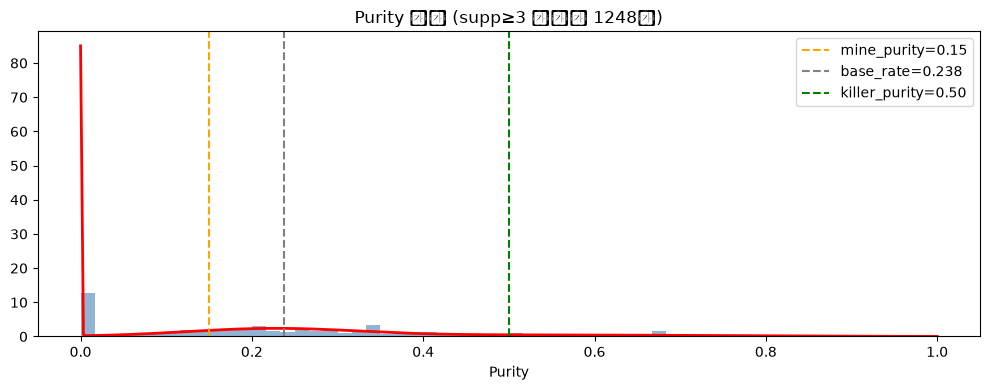

purity < 0.15: 458개
0.15 ~ 0.50: 622개
purity >= 0.50: 168개


In [32]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import numpy as np

# scores_df 대신 노트북에 이미 있는 변수 사용
purity = purity_arr[supp_all >= 3]  # Cell 8에서 정의된 변수들

# 히스토그램
plt.figure(figsize=(10, 4))
plt.hist(purity, bins=60, density=True, alpha=0.6, color='steelblue')

# GMM 3-component 피팅
gmm = GaussianMixture(n_components=3, random_state=42).fit(purity.reshape(-1,1))
x = np.linspace(0, 1, 300).reshape(-1,1)
plt.plot(x, np.exp(gmm.score_samples(x)), color='red', lw=2)

# 현재 파라미터 위치 표시
plt.axvline(0.15, color='orange', ls='--', label='mine_purity=0.15')
plt.axvline(0.238, color='gray', ls='--', label='base_rate=0.238')
plt.axvline(0.50, color='green', ls='--', label='killer_purity=0.50')

plt.xlabel('Purity'); plt.legend()
plt.title(f'Purity 분포 (supp≥3 키워드 {len(purity)}개)')
plt.tight_layout(); plt.show()

print(f"purity < 0.15: {(purity < 0.15).sum()}개")
print(f"0.15 ~ 0.50: {((purity >= 0.15) & (purity < 0.50)).sum()}개")
print(f"purity >= 0.50: {(purity >= 0.50).sum()}개")


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/3465891415.py:34: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/3465891415.py:34: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/3465891415.py:34: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/3465891415.py:34: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/3465891415.py:34: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.s

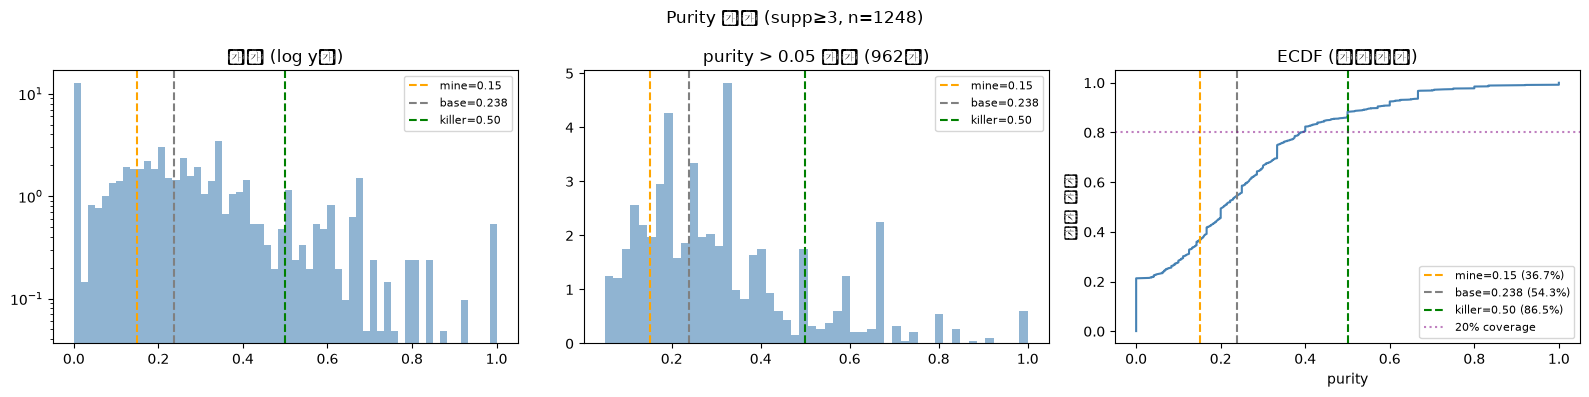

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ① 전체 뷰 (log y축)
axes[0].hist(purity, bins=60, density=True, alpha=0.6, color='steelblue')
axes[0].set_yscale('log')
axes[0].axvline(0.15, color='orange', ls='--', label='mine=0.15')
axes[0].axvline(0.238, color='gray', ls='--', label='base=0.238')
axes[0].axvline(0.50, color='green', ls='--', label='killer=0.50')
axes[0].set_title('전체 (log y축)')
axes[0].legend(fontsize=8)

# ② 0.05~1.0 구간 확대 (spike 제외)
purity_mid = purity[purity > 0.05]
axes[1].hist(purity_mid, bins=50, density=True, alpha=0.6, color='steelblue')
axes[1].axvline(0.15, color='orange', ls='--', label='mine=0.15')
axes[1].axvline(0.238, color='gray', ls='--', label='base=0.238')
axes[1].axvline(0.50, color='green', ls='--', label='killer=0.50')
axes[1].set_title(f'purity > 0.05 확대 ({len(purity_mid)}개)')
axes[1].legend(fontsize=8)

# ③ 누적분포(ECDF) — 자연 경계 확인
purity_sorted = np.sort(purity)
ecdf = np.arange(1, len(purity_sorted)+1) / len(purity_sorted)
axes[2].plot(purity_sorted, ecdf, color='steelblue', lw=1.5)
axes[2].axvline(0.15, color='orange', ls='--', label=f'mine=0.15 ({(purity<0.15).mean():.1%})')
axes[2].axvline(0.238, color='gray', ls='--', label=f'base=0.238 ({(purity<0.238).mean():.1%})')
axes[2].axvline(0.50, color='green', ls='--', label=f'killer=0.50 ({(purity<0.50).mean():.1%})')
axes[2].axhline(0.80, color='purple', ls=':', alpha=0.5, label='20% coverage')
axes[2].set_title('ECDF (누적분포)')
axes[2].set_xlabel('purity'); axes[2].set_ylabel('누적 비율')
axes[2].legend(fontsize=8)

plt.suptitle(f'Purity 분포 (supp≥3, n={len(purity)})')
plt.tight_layout(); plt.show()


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1442934278.py:23: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1442934278.py:23: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1442934278.py:23: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1442934278.py:23: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1442934278.py:23: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

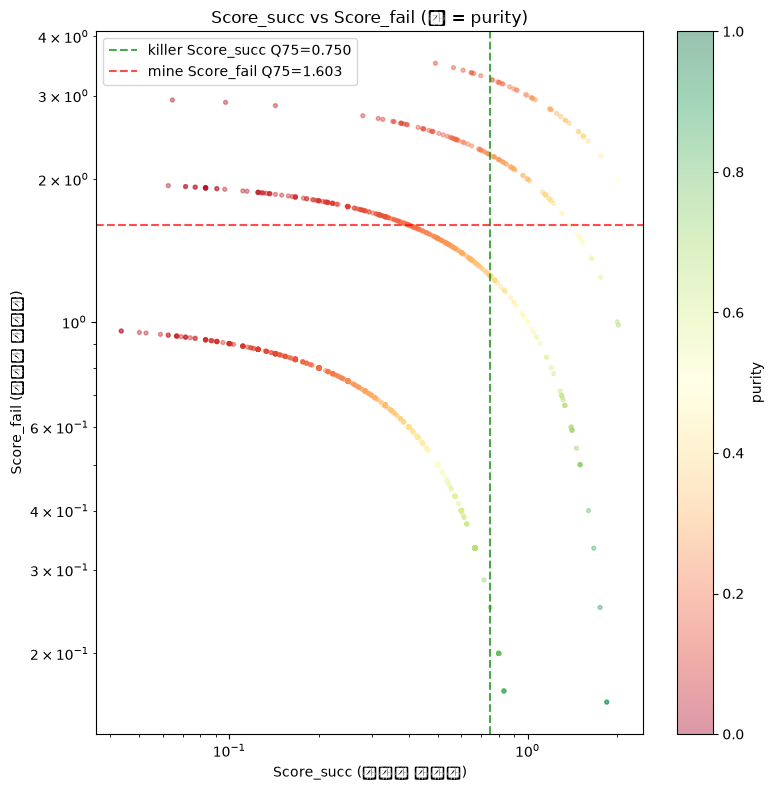

In [34]:
import matplotlib.pyplot as plt

score_s = lg.score_succ
score_f = lg.score_fail
mask = supp_all >= 3

plt.figure(figsize=(8, 8))
plt.scatter(score_s[mask], score_f[mask], 
            c=purity_arr[mask], cmap='RdYlGn',
            alpha=0.4, s=8, vmin=0, vmax=1)
plt.colorbar(label='purity')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('Score_succ (성공망 영향력)')
plt.ylabel('Score_fail (실패망 영향력)')

# 현재 threshold 선 (Q75 기준 대략)
k_thr = np.quantile(score_s[supp_s >= 3], 0.75)
m_thr = np.quantile(score_f[supp_f >= 3], 0.75)
plt.axvline(k_thr, color='green', ls='--', alpha=0.7, label=f'killer Score_succ Q75={k_thr:.3f}')
plt.axhline(m_thr, color='red', ls='--', alpha=0.7, label=f'mine Score_fail Q75={m_thr:.3f}')

plt.legend(); plt.title('Score_succ vs Score_fail (색 = purity)')
plt.tight_layout(); plt.show()


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/4158154123.py:63: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/4158154123.py:63: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/4158154123.py:63: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/4158154123.py:63: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/4158154123.py:63: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); pl

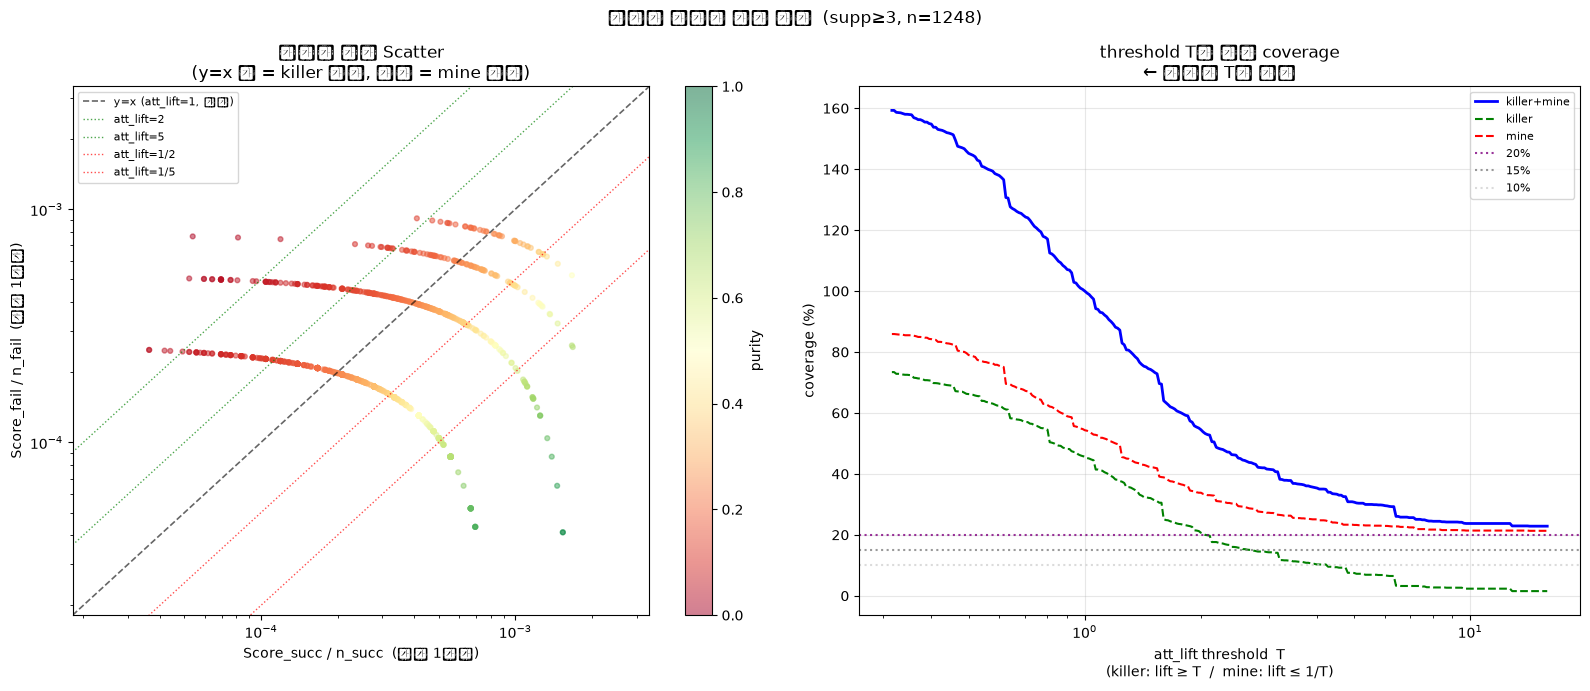

  coverage att_lift_thr   killer     mine    total
--------------------------------------------------
       10%        14.273        19       266       285
       15%        14.273        19       266       285
       20%        14.273        19       266       285
       25%         7.225        40       273       313


In [35]:
import matplotlib.pyplot as plt
import numpy as np

# ── 클래스 불균형 보정 ──────────────────────────────────────
# n_succ=1197, n_fail=3836 로 나눠서 "제품 1개당 평균 어텐션"으로 변환
s_succ_norm = lg.score_succ / n_succ
s_fail_norm = lg.score_fail / n_fail

mask = supp_all >= 3
x = s_succ_norm[mask]   # 성공 제품당 평균 어텐션
y_s = s_fail_norm[mask] # 실패 제품당 평균 어텐션
p   = purity_arr[mask]
lift_all = x / (y_s + 1e-9)  # 보정 att_lift (= 위 두 값의 비율)
n_total = mask.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── 왼쪽: 보정 scatter ─────────────────────────────────────
ax = axes[0]
sc = ax.scatter(x, y_s, c=p, cmap='RdYlGn', alpha=0.5, s=12, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='purity')
ax.set_xscale('log'); ax.set_yscale('log')

# y=x 중립선 + att_lift 등고선
lim_lo = min(x[x>0].min(), y_s[y_s>0].min()) * 0.5
lim_hi = max(x.max(), y_s.max()) * 2
lim = [lim_lo, lim_hi]

ax.plot(lim, lim, 'k--', lw=1.2, alpha=0.6, label='y=x (att_lift=1, 중립)')
for lift, col in [(2,'green'),(5,'green'),(0.5,'red'),(0.2,'red')]:
    label = f'att_lift={lift}' if lift >= 1 else f'att_lift=1/{int(1/lift)}'
    ax.plot(lim, [v * lift for v in lim], color=col, lw=1, ls=':', alpha=0.7, label=label)

ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Score_succ / n_succ  (성공 1개당)')
ax.set_ylabel('Score_fail / n_fail  (실패 1개당)')
ax.set_title('클래스 보정 Scatter\n(y=x 위 = killer 영역, 아래 = mine 영역)')
ax.legend(fontsize=8)

# ── 오른쪽: coverage 역산 ──────────────────────────────────
ax2 = axes[1]

thresholds = np.logspace(-0.5, 1.2, 300)  # att_lift threshold 범위
killer_n = [(lift_all >= t).sum() for t in thresholds]
mine_n   = [(lift_all <= 1/t).sum() for t in thresholds]
total_n  = [k + m for k, m in zip(killer_n, mine_n)]

ax2.plot(thresholds, [t/n_total*100 for t in total_n],  'b-',  lw=2,   label='killer+mine')
ax2.plot(thresholds, [k/n_total*100 for k in killer_n], 'g--', lw=1.5, label='killer')
ax2.plot(thresholds, [m/n_total*100 for m in mine_n],   'r--', lw=1.5, label='mine')

# 목표 coverage 선
for pct, col in [(20,'purple'),(15,'gray'),(10,'lightgray')]:
    ax2.axhline(pct, color=col, ls=':', lw=1.5, alpha=0.8, label=f'{pct}%')

ax2.set_xscale('log')
ax2.set_xlabel('att_lift threshold  T\n(killer: lift ≥ T  /  mine: lift ≤ 1/T)')
ax2.set_ylabel('coverage (%)')
ax2.set_title('threshold T에 따른 coverage\n← 여기서 T를 결정')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle(f'클래스 불균형 보정 분석  (supp≥3, n={n_total})', fontsize=12)
plt.tight_layout(); plt.show()

# ── 수치 요약 ──────────────────────────────────────────────
print(f"{'coverage':>10} {'att_lift_thr':>12} {'killer':>8} {'mine':>8} {'total':>8}")
print("-" * 50)
for target_pct in [10, 15, 20, 25]:
    idx = np.argmin(np.abs(np.array([t/n_total*100 for t in total_n]) - target_pct))
    t = thresholds[idx]
    print(f"{target_pct:>9}%  {t:>12.3f}  {killer_n[idx]:>8}  {mine_n[idx]:>8}  {total_n[idx]:>8}")


"커트라인(T)을 몇 점으로 잡아야 우리가 원하는 만큼의 단어가 뽑힐까?"를 알아내는 역산 시뮬레이션입니다.

In [37]:
import networkx as nx

# ── 캐시에서 엣지 추출 ─────────────────────────────────────
y_arr = eng.cache["y"]
K     = eng.cache["K"]
ei    = eng.cache["eidx"][("product","has_kw","keyword")].numpy()
ps_g, ks_g = ei[0], ei[1]

# ── 그래프 구성 ────────────────────────────────────────────
G_succ = nx.Graph()
G_fail = nx.Graph()
G_all  = nx.Graph()

for p_idx, k_idx in zip(ps_g, ks_g):
    pn, kn = f"P{p_idx}", f"K{k_idx}"
    G_all.add_edge(pn, kn)
    if y_arr[p_idx] == 1:
        G_succ.add_edge(pn, kn)
    else:
        G_fail.add_edge(pn, kn)

kw_nodes = [f"K{k}" for k in range(K)]
print(f"G_succ: {G_succ.number_of_nodes()}노드 / {G_succ.number_of_edges()}엣지")
print(f"G_fail: {G_fail.number_of_nodes()}노드 / {G_fail.number_of_edges()}엣지")
print(f"G_all:  {G_all.number_of_nodes()}노드  / {G_all.number_of_edges()}엣지")

# ── 중심성 계산 ────────────────────────────────────────────
print("\ndegree centrality...")
deg_s = nx.degree_centrality(G_succ)
deg_f = nx.degree_centrality(G_fail)

print("eigenvector centrality...")
try:
    eig_s = nx.eigenvector_centrality(G_succ, max_iter=2000, tol=1e-4)
    eig_f = nx.eigenvector_centrality(G_fail, max_iter=2000, tol=1e-4)
except nx.PowerIterationFailedConvergence:
    print("  미수렴 → degree로 대체")
    eig_s, eig_f = deg_s, deg_f

print("betweenness centrality (k=300 샘플링)...")
btw_a = nx.betweenness_centrality(G_all, k=300, seed=42)
print("완료")


G_succ: 2231노드 / 10315엣지
G_fail: 5620노드 / 27018엣지
G_all:  6955노드  / 37333엣지

degree centrality...
eigenvector centrality...
betweenness centrality (k=300 샘플링)...
완료


In [39]:
import networkx as nx

# ── 캐시에서 엣지 추출 ─────────────────────────────────────
y_arr = eng.cache["y"]
K     = eng.cache["K"]
ei    = eng.cache["eidx"][("product","has_kw","keyword")].numpy()
ps_g, ks_g = ei[0], ei[1]

# ── 그래프 구성 ────────────────────────────────────────────
G_succ = nx.Graph()
G_fail = nx.Graph()
G_all  = nx.Graph()

for p_idx, k_idx in zip(ps_g, ks_g):
    pn, kn = f"P{p_idx}", f"K{k_idx}"
    G_all.add_edge(pn, kn)
    if y_arr[p_idx] == 1:
        G_succ.add_edge(pn, kn)
    else:
        G_fail.add_edge(pn, kn)

kw_nodes = [f"K{k}" for k in range(K)]
print(f"G_succ: {G_succ.number_of_nodes()}노드 / {G_succ.number_of_edges()}엣지")
print(f"G_fail: {G_fail.number_of_nodes()}노드 / {G_fail.number_of_edges()}엣지")
print(f"G_all:  {G_all.number_of_nodes()}노드  / {G_all.number_of_edges()}엣지")

# ── 중심성 계산 ────────────────────────────────────────────
print("\ndegree centrality...")
deg_s = nx.degree_centrality(G_succ)
deg_f = nx.degree_centrality(G_fail)

print("eigenvector centrality...")
try:
    eig_s = nx.eigenvector_centrality(G_succ, max_iter=2000, tol=1e-4)
    eig_f = nx.eigenvector_centrality(G_fail, max_iter=2000, tol=1e-4)
except nx.PowerIterationFailedConvergence:
    print("  미수렴 → degree로 대체")
    eig_s, eig_f = deg_s, deg_f

print("betweenness centrality...")
btw_a = nx.betweenness_centrality(G_all, seed=42)
print("완료")


G_succ: 2231노드 / 10315엣지
G_fail: 5620노드 / 27018엣지
G_all:  6955노드  / 37333엣지

degree centrality...
eigenvector centrality...
betweenness centrality...
완료


=== 그룹별 중심성 중앙값 ===
         deg_succ  deg_fail  deg_ratio  eig_succ  eig_fail  eig_ratio  \
tag                                                                     
hub      0.001794  0.002670   0.917712  0.002073  0.002849   0.856053   
killer   0.001345  0.000178   7.559150  0.001123  0.000076   4.963159   
mine     0.000000  0.001246   0.000000  0.000000  0.000680   0.000000   
neutral  0.000448  0.000890   0.627591  0.000437  0.000677   0.500661   

          btw_all  
tag                
hub      0.000051  
killer   0.000001  
mine     0.000024  
neutral  0.000008  


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1758258084.py:73: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1758258084.py:73: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1758258084.py:73: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1758258084.py:73: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1758258084.py:73: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt

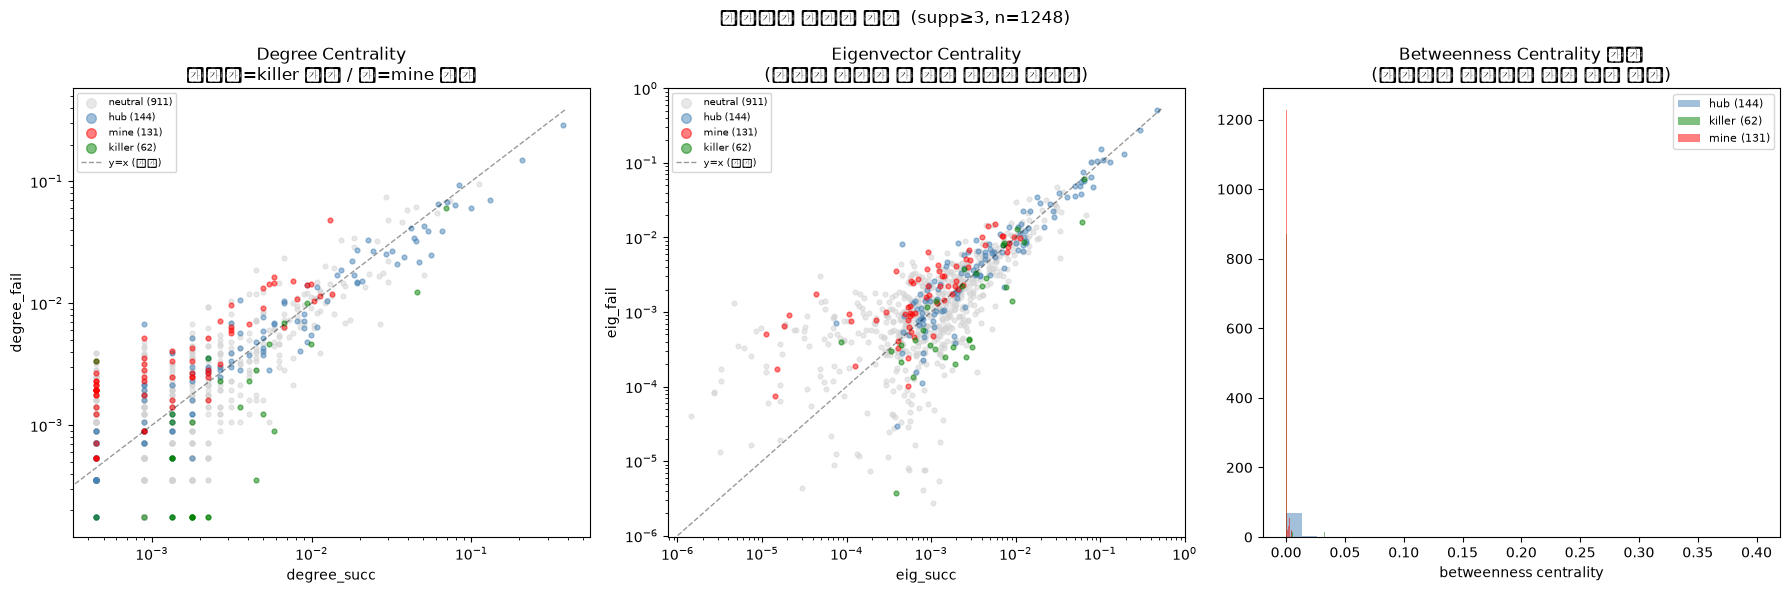

In [40]:
# 샘플링 없는 시각화 
import pandas as pd
import matplotlib.pyplot as plt

# ── DataFrame 구성 ─────────────────────────────────────────
killer_set = set(lg.killer)
mine_set   = set(lg.mine)
hub_set    = set(lg.hub)

rows = []
for k_idx in range(K):
    kn = f"K{k_idx}"
    rows.append({
        "keyword"  : eng.kw_name(k_idx),
        "deg_succ" : deg_s.get(kn, 0),
        "deg_fail" : deg_f.get(kn, 0),
        "eig_succ" : eig_s.get(kn, 0),
        "eig_fail" : eig_f.get(kn, 0),
        "btw_all"  : btw_a.get(kn, 0),
        "purity"   : purity_arr[k_idx],
        "supp_all" : int(supp_all[k_idx]),
        "tag"      : ("killer" if k_idx in killer_set else
                      "mine"   if k_idx in mine_set   else
                      "hub"    if k_idx in hub_set     else "neutral"),
    })

df_cent = pd.DataFrame(rows)
df_cent["deg_ratio"] = df_cent["deg_succ"] / (df_cent["deg_fail"] + 1e-9)
df_cent["eig_ratio"] = df_cent["eig_succ"] / (df_cent["eig_fail"] + 1e-9)

# ── 그룹별 중앙값 요약 ─────────────────────────────────────
mask = df_cent["supp_all"] >= 3
print("=== 그룹별 중심성 중앙값 ===")
print(df_cent[mask].groupby("tag")[
    ["deg_succ","deg_fail","deg_ratio","eig_succ","eig_fail","eig_ratio","btw_all"]
].median().round(6))

# ── 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {"killer":"green","mine":"red","hub":"steelblue","neutral":"lightgray"}

for tag in ["neutral","hub","mine","killer"]:
    grp = df_cent[mask & (df_cent["tag"]==tag)]
    axes[0].scatter(grp["deg_succ"], grp["deg_fail"],
                    c=colors[tag], alpha=0.5, s=12, label=f"{tag} ({len(grp)})")
    axes[1].scatter(grp["eig_succ"], grp["eig_fail"],
                    c=colors[tag], alpha=0.5, s=12, label=f"{tag} ({len(grp)})")

# y=x 중립선
for ax in axes[:2]:
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo,hi],[lo,hi], 'k--', lw=1, alpha=0.4, label='y=x (중립)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.legend(fontsize=7, markerscale=2)

axes[0].set_xlabel('degree_succ'); axes[0].set_ylabel('degree_fail')
axes[0].set_title('Degree Centrality\n오른쪽=killer 영역 / 위=mine 영역')

axes[1].set_xlabel('eig_succ'); axes[1].set_ylabel('eig_fail')
axes[1].set_title('Eigenvector Centrality\n(중요한 제품에 더 많이 연결된 키워드)')

# Betweenness 분포
for tag in ["hub","killer","mine"]:
    grp = df_cent[mask & (df_cent["tag"]==tag)]["btw_all"]
    axes[2].hist(grp, bins=30, alpha=0.5, density=True,
                 color=colors[tag], label=f"{tag} ({len(grp)})")
axes[2].set_xlabel('betweenness centrality')
axes[2].set_title('Betweenness Centrality 분포\n(높을수록 네트워크 연결 다리 역할)')
axes[2].legend(fontsize=8)

plt.suptitle(f'네트워크 중심성 분석  (supp≥3, n={mask.sum()})', fontsize=12)
plt.tight_layout(); plt.show()


In [41]:
# hub 후보: betweenness 상위 20% + deg_ratio 0.5~2.5 (균형)
btw_vals = np.array([btw_a.get(f"K{k}", 0) for k in range(K)])
btw_q80 = np.quantile(btw_vals[supp_all >= 3], 0.80)

print(f"betweenness Q80 = {btw_q80:.6f}")
print(f"btw > Q80인 키워드 수: {(btw_vals >= btw_q80).sum()}개")
print(f"그 중 현재 hub 태그: {sum(1 for k in range(K) if btw_vals[k]>=btw_q80 and k in hub_set)}개")
print(f"그 중 현재 neutral 태그: {sum(1 for k in range(K) if btw_vals[k]>=btw_q80 and k not in hub_set|killer_set|mine_set)}개")


betweenness Q80 = 0.000171
btw > Q80인 키워드 수: 250개
그 중 현재 hub 태그: 60개
그 중 현재 neutral 태그: 155개


In [42]:
# 허브 정의 바꿨을때 결과
btw_vals = np.array([btw_a.get(f"K{k}", 0) for k in range(K)])

# ① balance: |purity - base_rate| < 0.15
balance_mask = np.abs(purity_arr - 0.238) < 0.15

# ② centrality A (현재): Hub_Score Q80
# ② centrality B (대안): betweenness Q80
btw_q80 = np.quantile(btw_vals[supp_all >= 3], 0.80)

hub_current  = balance_mask & (hub_score_arr >= np.quantile(hub_score_arr[supp_all>=3], 0.80)) & (supp_all >= 3)
hub_btw      = balance_mask & (btw_vals >= btw_q80) & (supp_all >= 3)
hub_both     = hub_current & hub_btw  # 교집합

print(f"현재 Hub_Score 기반: {hub_current.sum()}개")
print(f"Betweenness 기반:    {hub_btw.sum()}개")
print(f"두 방법 교집합:       {hub_both.sum()}개")


현재 Hub_Score 기반: 148개
Betweenness 기반:    209개
두 방법 교집합:       61개


=== 그룹별 중심성 중앙값 ===
         deg_succ  deg_fail  deg_ratio  eig_succ  eig_fail  eig_ratio  \
tag                                                                     
hub      0.001794  0.002670   0.917712  0.002073  0.002849   0.856053   
killer   0.001345  0.000178   7.559150  0.001123  0.000076   4.963159   
mine     0.000000  0.001246   0.000000  0.000000  0.000680   0.000000   
neutral  0.000448  0.000890   0.627591  0.000437  0.000677   0.500661   

          btw_all  
tag                
hub      0.000036  
killer   0.000000  
mine     0.000018  
neutral  0.000005  


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1634125688.py:73: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1634125688.py:73: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1634125688.py:73: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1634125688.py:73: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1634125688.py:73: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt

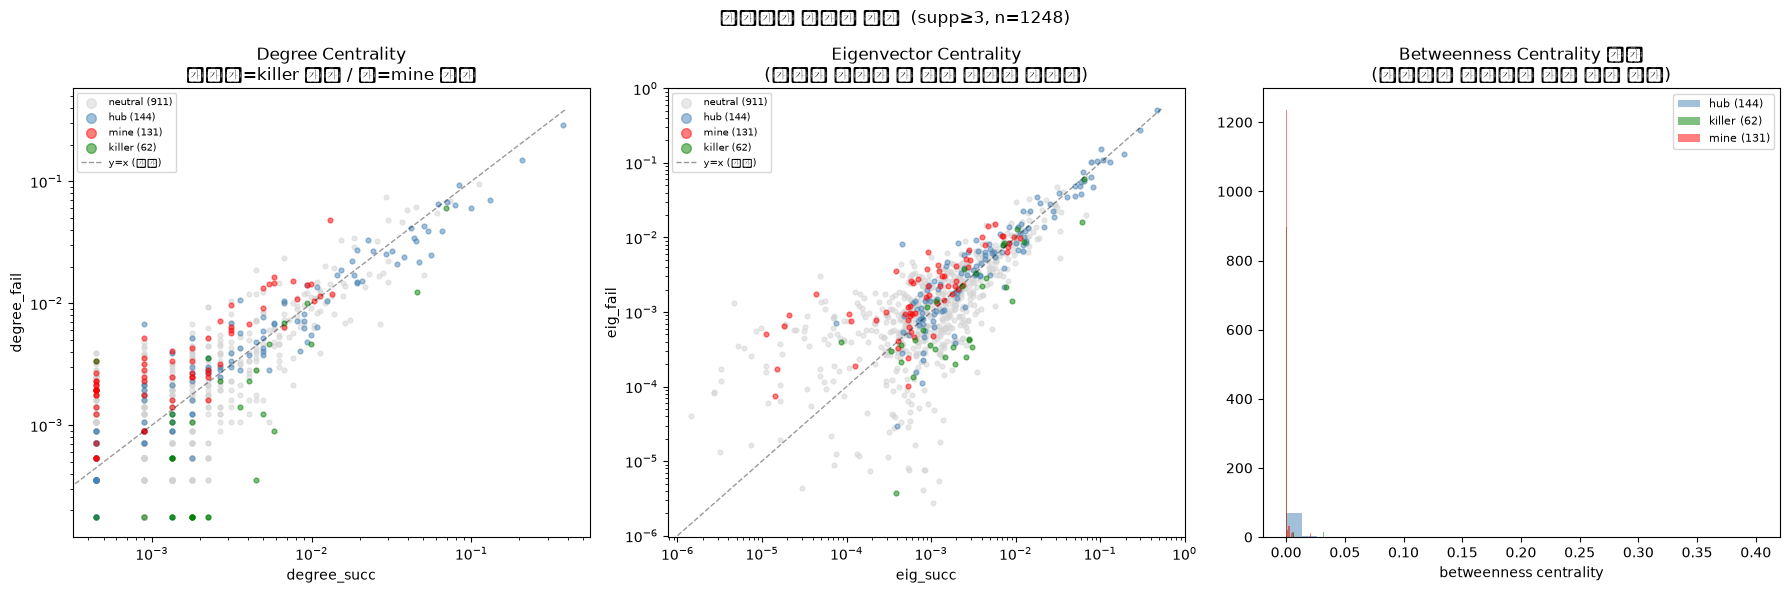

In [38]:
# 시각화 
import pandas as pd
import matplotlib.pyplot as plt

# ── DataFrame 구성 ─────────────────────────────────────────
killer_set = set(lg.killer)
mine_set   = set(lg.mine)
hub_set    = set(lg.hub)

rows = []
for k_idx in range(K):
    kn = f"K{k_idx}"
    rows.append({
        "keyword"  : eng.kw_name(k_idx),
        "deg_succ" : deg_s.get(kn, 0),
        "deg_fail" : deg_f.get(kn, 0),
        "eig_succ" : eig_s.get(kn, 0),
        "eig_fail" : eig_f.get(kn, 0),
        "btw_all"  : btw_a.get(kn, 0),
        "purity"   : purity_arr[k_idx],
        "supp_all" : int(supp_all[k_idx]),
        "tag"      : ("killer" if k_idx in killer_set else
                      "mine"   if k_idx in mine_set   else
                      "hub"    if k_idx in hub_set     else "neutral"),
    })

df_cent = pd.DataFrame(rows)
df_cent["deg_ratio"] = df_cent["deg_succ"] / (df_cent["deg_fail"] + 1e-9)
df_cent["eig_ratio"] = df_cent["eig_succ"] / (df_cent["eig_fail"] + 1e-9)

# ── 그룹별 중앙값 요약 ─────────────────────────────────────
mask = df_cent["supp_all"] >= 3
print("=== 그룹별 중심성 중앙값 ===")
print(df_cent[mask].groupby("tag")[
    ["deg_succ","deg_fail","deg_ratio","eig_succ","eig_fail","eig_ratio","btw_all"]
].median().round(6))

# ── 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {"killer":"green","mine":"red","hub":"steelblue","neutral":"lightgray"}

for tag in ["neutral","hub","mine","killer"]:
    grp = df_cent[mask & (df_cent["tag"]==tag)]
    axes[0].scatter(grp["deg_succ"], grp["deg_fail"],
                    c=colors[tag], alpha=0.5, s=12, label=f"{tag} ({len(grp)})")
    axes[1].scatter(grp["eig_succ"], grp["eig_fail"],
                    c=colors[tag], alpha=0.5, s=12, label=f"{tag} ({len(grp)})")

# y=x 중립선
for ax in axes[:2]:
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo,hi],[lo,hi], 'k--', lw=1, alpha=0.4, label='y=x (중립)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.legend(fontsize=7, markerscale=2)

axes[0].set_xlabel('degree_succ'); axes[0].set_ylabel('degree_fail')
axes[0].set_title('Degree Centrality\n오른쪽=killer 영역 / 위=mine 영역')

axes[1].set_xlabel('eig_succ'); axes[1].set_ylabel('eig_fail')
axes[1].set_title('Eigenvector Centrality\n(중요한 제품에 더 많이 연결된 키워드)')

# Betweenness 분포
for tag in ["hub","killer","mine"]:
    grp = df_cent[mask & (df_cent["tag"]==tag)]["btw_all"]
    axes[2].hist(grp, bins=30, alpha=0.5, density=True,
                 color=colors[tag], label=f"{tag} ({len(grp)})")
axes[2].set_xlabel('betweenness centrality')
axes[2].set_title('Betweenness Centrality 분포\n(높을수록 네트워크 연결 다리 역할)')
axes[2].legend(fontsize=8)

plt.suptitle(f'네트워크 중심성 분석  (supp≥3, n={mask.sum()})', fontsize=12)
plt.tight_layout(); plt.show()


## 허브 분리하기

Text(0.5, 1.0, 'Balance 거리 분포 — eps 기준점 탐색')

/Users/hajiyoon/workspace/711project/7eleven_npd_share이전/.venv/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hajiyoon/workspace/711project/7eleven_npd_share이전/.venv/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hajiyoon/workspace/711project/7eleven_npd_share이전/.venv/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hajiyoon/workspace/711project/7eleven_npd_share이전/.venv/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/hajiyoon/workspace/711project/7eleven_npd_share이전/.venv/lib/pyth

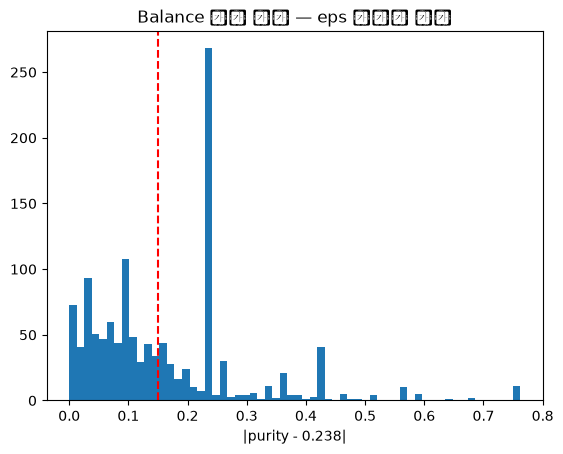

In [43]:
balance_dist = np.abs(purity_arr[supp_all >= 3] - 0.238)
plt.hist(balance_dist, bins=60)
plt.axvline(0.15, color='red', ls='--', label='현재 eps=0.15')
plt.xlabel('|purity - 0.238|')
plt.title('Balance 거리 분포 — eps 기준점 탐색')


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1322634539.py:20: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1322634539.py:20: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1322634539.py:20: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Users/hajiyoon/workspace/711project/7eleven_npd_share이전/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hajiyoon/workspace/711project/7eleven_npd_share이전/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 

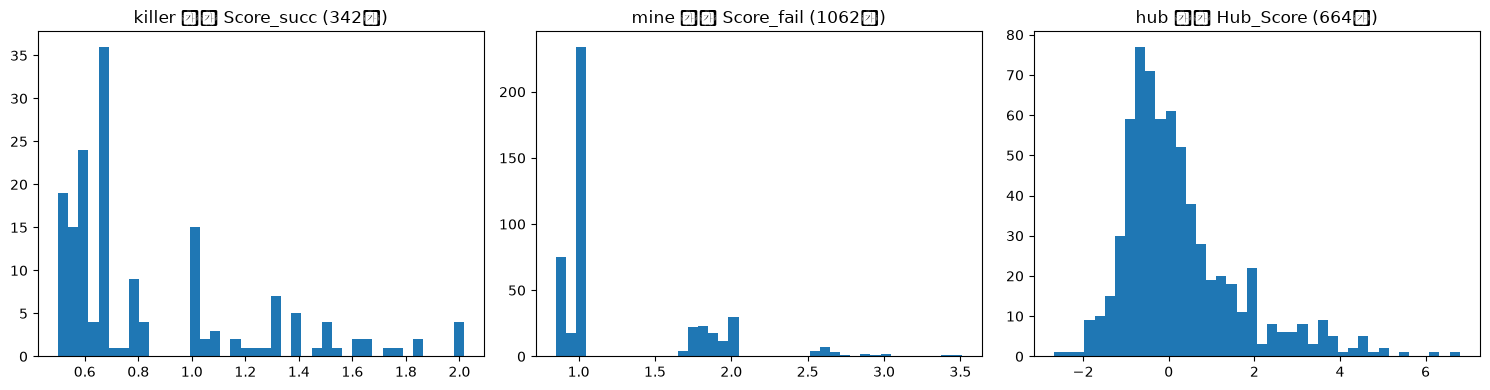

killer 후보: 168개
mine 후보:   458개
hub 후보:    664개


In [45]:
# Step 1: 각 후보군의 Score 분포 확인 (10분)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# killer 후보군 (purity ≥ 0.50)
killer_cand = purity_arr >= 0.50
axes[0].hist(lg.score_succ[killer_cand & (supp_all>=3)], bins=40)
axes[0].set_title(f'killer 후보 Score_succ ({killer_cand.sum()}개)')

# mine 후보군 (purity ≤ 0.15)
mine_cand = purity_arr <= 0.15
axes[1].hist(lg.score_fail[mine_cand & (supp_all>=3)], bins=40)
axes[1].set_title(f'mine 후보 Score_fail ({mine_cand.sum()}개)')

# hub 후보군 (|purity-0.238| < 0.15)
hub_cand = np.abs(purity_arr - 0.238) < 0.15
axes[2].hist(hub_score_arr[hub_cand & (supp_all>=3)], bins=40)
axes[2].set_title(f'hub 후보 Hub_Score ({hub_cand.sum()}개)')

plt.tight_layout(); plt.show()
print(f"killer 후보: {(killer_cand & (supp_all>=3)).sum()}개")
print(f"mine 후보:   {(mine_cand   & (supp_all>=3)).sum()}개")
print(f"hub 후보:    {(hub_cand    & (supp_all>=3)).sum()}개")


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1844459292.py:15: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1844459292.py:15: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/1844459292.py:15: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Users/hajiyoon/workspace/711project/7eleven_npd_share이전/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hajiyoon/workspace/711project/7eleven_npd_share이전/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Gl

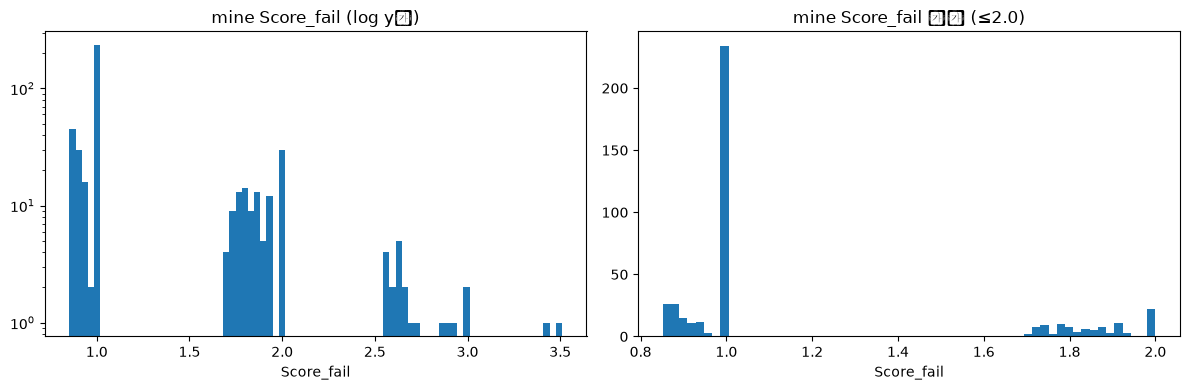

Q25 = 1.000  (356개)
Q50 = 1.000  (306개)
Q75 = 1.750  (115개)
Q90 = 2.000  (49개)
Q95 = 2.000  (23개)


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mine_scores = lg.score_fail[mine_cand & (supp_all>=3)]

# log scale
axes[0].hist(mine_scores, bins=80, log=True)
axes[0].set_title('mine Score_fail (log y축)')
axes[0].set_xlabel('Score_fail')

# 1.0~2.0 구간 확대
axes[1].hist(mine_scores[mine_scores <= 2.0], bins=60)
axes[1].set_title('mine Score_fail 확대 (≤2.0)')
axes[1].set_xlabel('Score_fail')

plt.tight_layout(); plt.show()

# 분위수 확인
for q in [0.25, 0.50, 0.75, 0.90, 0.95]:
    print(f"Q{int(q*100):2d} = {np.quantile(mine_scores, q):.3f}  ({int((mine_scores >= np.quantile(mine_scores, q)).sum())}개)")


/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/3945399859.py:10: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/3945399859.py:10: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/y9/_xbnh5z57m96hljq1krz11tr0000gn/T/ipykernel_19350/3945399859.py:10: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


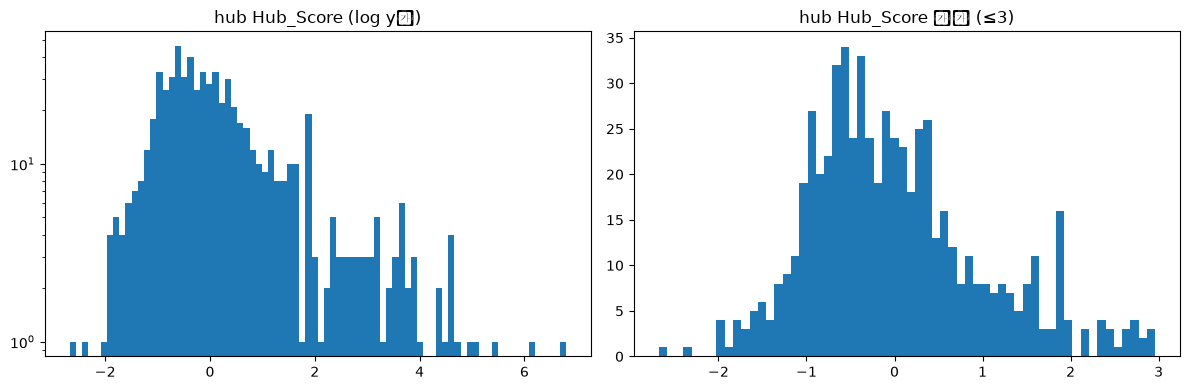

Q25 = -0.646  (498개)
Q50 = -0.075  (332개)
Q75 = 0.732  (166개)
Q90 = 1.925  (67개)


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hub_scores = hub_score_arr[hub_cand & (supp_all>=3)]

axes[0].hist(hub_scores, bins=80, log=True)
axes[0].set_title('hub Hub_Score (log y축)')

axes[1].hist(hub_scores[hub_scores <= 3], bins=60)
axes[1].set_title('hub Hub_Score 확대 (≤3)')

plt.tight_layout(); plt.show()

for q in [0.25, 0.50, 0.75, 0.90]:
    print(f"Q{int(q*100):2d} = {np.quantile(hub_scores, q):.3f}  ({int((hub_scores >= np.quantile(hub_scores, q)).sum())}개)")


Text(0.5, 1.0, 'Hub_Score ECDF')

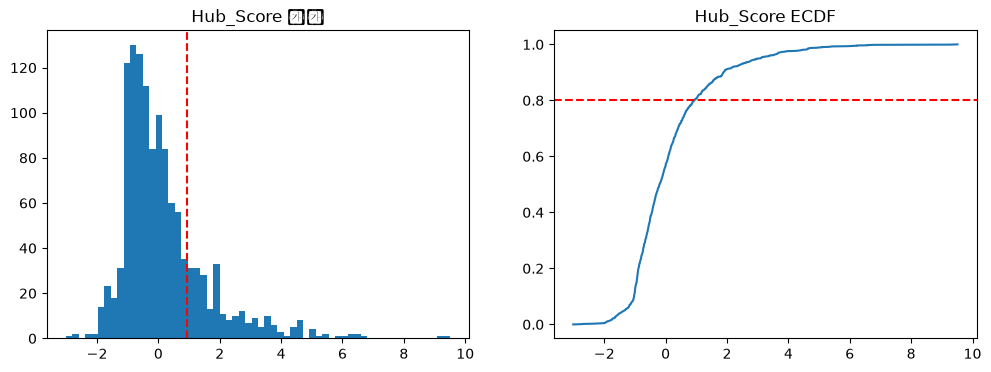

In [44]:
hs = hub_score_arr[supp_all >= 3]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(hs, bins=60)
axes[0].axvline(np.quantile(hs, 0.80), color='red', ls='--', label='현재 Q80')
axes[0].set_title('Hub_Score 분포')

# ECDF
axes[1].plot(np.sort(hs), np.linspace(0, 1, len(hs)))
axes[1].axhline(0.80, color='red', ls='--', label='Q80')
axes[1].set_title('Hub_Score ECDF')


In [49]:
# 어떤 속성이 있는지 확인
print([a for a in dir(eng) if not a.startswith('_')])

# cache 키 확인
print(eng.cache.keys())


['build_ledger', 'build_mass', 'cache', 'cfg', 'confusion_quadrant', 'data', 'delta_prob', 'device', 'is_v2', 'kw_name', 'ledger', 'mass', 'model', 'product_keywords', 'run_single_inference', 'save_cache', 'score_concept', 'seed_to_idx']
dict_keys(['ckpt_config', 'maps', 'prob', 'y', 'att', 'eidx', 'eattr', 'has_promo', 'insta_m30', 'channel', 'succ_src', 'train_mask', 'val_mask', 'test_mask', 'P', 'K', 'I', 'base_rate', 'k2i', 'kw_ids', 'product_ids', 'product_names', 'mass_raw'])


In [54]:
# 인덱스 → 키워드명 역매핑
i2k = {v: k for k, v in eng.cache['k2i'].items()}
kw_names = [i2k[i] for i in range(eng.cache['K'])]

df_kw = pd.DataFrame({
    'keyword'   : kw_names,
    'purity'    : purity_arr,
    'score_succ': lg.score_succ,
    'score_fail': lg.score_fail,
    'hub_score' : hub_score_arr,
    'supp_s'    : supp_s,
    'supp_f'    : supp_f,
    'supp_all'  : supp_all,
})

# killer/mine/hub 각각 다른 elig 기준 사용
elig_k = supp_s   >= 3
elig_m = supp_f   >= 3
elig_h = supp_all >= 3

k_thr = np.quantile(lg.score_succ[elig_k], 0.75)
m_thr = np.quantile(lg.score_fail[elig_m], 0.75)
h_thr = np.quantile(hub_score_arr[elig_h], 0.80)

print(f"k_thr={k_thr:.4f}, m_thr={m_thr:.4f}, h_thr={h_thr:.4f}")

df_kw['tag'] = 'neutral'
df_kw.loc[elig_k & (purity_arr >= 0.50) & (lg.score_succ >= k_thr), 'tag'] = 'killer'
df_kw.loc[elig_m & (purity_arr <= 0.15) & (lg.score_fail >= m_thr), 'tag'] = 'mine'
hub_cond = elig_h & (np.abs(purity_arr - 0.238) < 0.15) & (hub_score_arr >= h_thr)
df_kw.loc[hub_cond & (df_kw['tag'] == 'neutral'), 'tag'] = 'hub'

print(df_kw['tag'].value_counts())

# 그룹별 키워드 출력
for tag, sort_col, asc in [
    ('killer', 'score_succ', False),
    ('mine',   'score_fail', False),
    ('hub',    'hub_score',  False),
]:
    sub = df_kw[df_kw['tag'] == tag].sort_values(sort_col, ascending=asc)
    print(f"\n{'='*50}")
    print(f"[{tag}] {len(sub)}개")
    print(sub[['keyword','purity','supp_s','supp_f']].head(30).to_string(index=False))


k_thr=0.7497, m_thr=1.6029, h_thr=0.9357
tag
neutral    1726
hub         144
mine        131
killer       62
Name: count, dtype: int64

[killer] 62개
keyword   purity  supp_s  supp_f
    띠부씰 0.671996      62     118
     매콤 0.500103     256     721
     도쿄 1.000000       3       0
     공룡 0.921051      17       3
     일식 0.921045      16       3
    옥수수 0.585928      29      52
     뷰티 0.874994       7       2
    활기참 0.833333       5       2
   샌드위치 0.547261      38      87
     호두 0.544701     120     255
     여유 0.799996       7       2
   커스터드 0.511230      69     133
    돈까스 0.506403      15      25
    콜라겐 0.750001       6       3
     족발 0.750000       4       3
      흰 0.749998      17       3
    말랑함 0.729168      23      26
     슈거 0.704548      10      13
     남도 0.704547      11       2
     명장 0.704541      10       3
      게 0.700002       5       6
     공주 0.700000      11      15
     토닉 0.666667       3       6
     모찌 0.657899      12      26
     예술 0.653847       5  

In [57]:
# att_lift, woe 같이 사용
woe = np.log((supp_s / n_succ + 1e-9) / (supp_f / n_fail + 1e-9))
df_kw['woe']      = woe
df_kw['att_lift'] = (lg.score_succ / n_succ) / (lg.score_fail / n_fail + 1e-9)

# killer 중 두 지표 동시 확인
killer_df = df_kw[df_kw['tag'] == 'killer'].sort_values('att_lift')
print(killer_df[['keyword','purity','supp_s','supp_f','woe','att_lift']].to_string(index=False))


keyword   purity  supp_s  supp_f       woe     att_lift
    가정식 0.500000       4       1  2.550903 3.204666e+00
    강아지 0.500000      14       1  3.803665 3.204666e+00
     매콤 0.500103     256     721  0.129150 3.205987e+00
    돈까스 0.506403      15      25  0.653786 3.287819e+00
   커스터드 0.511230      69     133  0.508369 3.351937e+00
    폭신함 0.517539     194     480  0.258684 3.437667e+00
     소주 0.525001       3      19 -0.681215 3.542006e+00
     푸드 0.536033      17      23  0.862331 3.702429e+00
     호두 0.544701     120     255  0.410840 3.833935e+00
   샌드위치 0.547261      38      87  0.336290 3.873733e+00
    비타민 0.550009      11      10  1.259922 3.916948e+00
     효모 0.578124       6      27 -0.339466 4.391564e+00
     한정 0.579489     107      76  1.506707 4.416223e+00
    옥수수 0.585928      29      52  0.580664 4.534736e+00
     양파 0.600001       6      20 -0.039361 4.807005e+00
     편함 0.611107       3       7  0.317314 5.035811e+00
     재미 0.642842       6      15  0.248321 5.768

In [58]:
att_lift = (lg.score_succ / n_succ) / (lg.score_fail / n_fail + 1e-9)
woe      = np.log((supp_s / n_succ + 1e-9) / (supp_f / n_fail + 1e-9))

df_kw['att_lift'] = att_lift
df_kw['woe']      = woe

# ── killer ──────────────────────────────────────
killer_base = elig_k & (purity_arr >= 0.50) & (lg.score_succ >= k_thr)
killer_confirmed = killer_base & (woe > 0) & (supp_f > 0)

# ── mine (대칭) ──────────────────────────────────
mine_base = elig_m & (purity_arr <= 0.15) & (lg.score_fail >= m_thr)
mine_confirmed = mine_base & (woe < 0) & (supp_s > 0)

# ── hub ─────────────────────────────────────────
hub_base = elig_h & (np.abs(purity_arr - 0.238) < 0.15) & (hub_score_arr >= h_thr)
hub_confirmed = hub_base & ~killer_confirmed & ~mine_confirmed

df_kw['tag'] = 'neutral'
df_kw.loc[killer_confirmed, 'tag'] = 'killer'
df_kw.loc[mine_confirmed,   'tag'] = 'mine'
df_kw.loc[hub_confirmed,    'tag'] = 'hub'

print(df_kw['tag'].value_counts())

# hub WoE + att_lift 분포 확인 (균형 조건 추가 전 현황)
hub_df = df_kw[df_kw['tag'] == 'hub']
print(f"\n--- hub WoE 분포 ---")
print(hub_df['woe'].describe())
print(f"\n--- hub att_lift 분포 ---")
print(hub_df['att_lift'].describe())


tag
neutral    1785
hub         146
mine         84
killer       48
Name: count, dtype: int64

--- hub WoE 분포 ---
count    146.000000
mean       0.193447
std        0.393009
min       -1.474445
25%        0.021207
50%        0.247098
75%        0.471464
max        1.318762
Name: woe, dtype: float64

--- hub att_lift 분포 ---
count    146.000000
mean       1.228368
std        0.443891
min        0.369773
25%        0.809808
50%        1.234388
75%        1.602344
max        2.017732
Name: att_lift, dtype: float64


In [59]:
# hub 균형 조건 추가
hub_balanced = hub_confirmed & (att_lift < 1.5) & (np.abs(woe) < 0.5)

# 조건 전/후 비교
print(f"hub (현재): {hub_confirmed.sum()}개")
print(f"hub (균형조건 추가): {hub_balanced.sum()}개")
print(f"탈락 키워드:")

dropped = df_kw[hub_confirmed & ~hub_balanced][['keyword','woe','att_lift']].sort_values('att_lift', ascending=False)
print(dropped.to_string(index=False))


hub (현재): 146개
hub (균형조건 추가): 79개
탈락 키워드:
keyword       woe  att_lift
      K  0.223628  2.017732
     고소  0.189885  2.007349
     초코  0.255453  1.999909
      빵  0.342388  1.993150
   부드러움  0.088789  1.983982
     맑음 -0.339465  1.972110
     어묵  0.727398  1.968115
     충전  0.424453  1.934937
    메이플  0.653786  1.922827
    부리또  0.653786  1.922812
    중독성  0.248321  1.922744
     핫바  0.776846  1.918158
    쫀득함  0.348276  1.912313
     촉촉  0.222957  1.910212
     버거  0.585409  1.905438
      바  0.240022  1.900777
     과자  0.368708  1.891649
   카스테라  0.633983  1.882127
     쿠키  0.376154  1.881341
 파운드케이크  0.604996  1.831227
     새콤  0.575411  1.827273
     와플 -0.123243  1.743725
    귀여움  0.506556  1.659486
     카레  0.532089  1.651415
     소금  0.119783  1.643127
     우유  0.338304  1.623024
    카라멜  0.203201  1.612948
     튀김  0.153011  1.603564
      빈  0.471464  1.602406
    씨솔트  0.471464  1.602395
   스크램블  0.471464  1.602392
    피카츄  0.471464  1.602372
   마가렛트  0.471464  1.602370
     씨